# Expected Distance Kernel Experiment

Comparison of probabilistic similarity functions for genome clustering:
adaptive Mahalanobis, identity form, and the **expected squared distance kernel**.

## Mathematical Derivations

### Background: Probabilistic Contrastive Learning

Each probabilistic model maps an input $x$ to a Gaussian embedding $z \sim \mathcal{N}(\boldsymbol{\mu}, \text{diag}(\boldsymbol{\sigma}^2))$. Training uses a contrastive BCE loss on the marginal similarity $p_{ij}$ between pairs $(z_i, z_j)$. The form of $p_{ij}$ depends on the kernel matrix $K$.

---

### General Formula (Lemma 3.1)

$$p_{ij} = \frac{1}{\sqrt{|K^{-1}(\Sigma_i+\Sigma_j)+I|}} \exp\!\left(-\frac{1}{2}\boldsymbol{\delta}^\top(\Sigma_i+\Sigma_j+K)^{-1}\boldsymbol{\delta}\right)$$

With diagonal $K = \text{diag}(k_1, \ldots, k_D)$ and $v_d = \sigma^2_{i,d} + \sigma^2_{j,d}$:

$$\log p_{ij} = -\frac{1}{2}\sum_d \left[\log\!\left(\frac{v_d}{k_d}+1\right) + \frac{\delta_d^2}{v_d + k_d}\right]$$

**Gradient w.r.t. variance** (the key to understanding all forms):

$$\frac{\partial \log p}{\partial v_d} = -\frac{1}{2(v_d + k_d)}\left[1 - \frac{\delta_d^2}{v_d + k_d}\right]$$

This **flips sign** at $\delta_d^2 = v_d + k_d$:
- **Below threshold** ($\delta^2 < v + k$): gradient is negative $\to$ pushes variance **DOWN**
- **Above threshold** ($\delta^2 > v + k$): gradient is positive $\to$ pushes variance **UP**

---

### Gradient Analysis by Pair Type (BCE Training)

| Pair type | $\delta^2$ | Positive pairs | Negative pairs | Desired |
|---|---|---|---|---|
| **Close + correct** | $\approx 0$ | loss grad > 0, var **DOWN** | N/A | var $\to$ 0, p=1 |
| **Close + confused** | $\approx 0$ | N/A | loss grad < 0, var **UP** | var fires up, p $\to$ 0 |
| **Far + wrong** | large | loss grad < 0, var **UP** | N/A | high uncertainty |
| **Far + correct** | large | N/A | loss grad > 0, var **DOWN** | var $\to$ 0, confident |

The general formula gives the **correct gradient direction for all four cases** when $k_d$ is a fixed constant.

---

### Form 1: Adaptive Mahalanobis ($K = \alpha(\Sigma_i + \Sigma_j)$)

**Training loss (Lemma 3.1):**

$$\log p_{ij} = -\frac{1}{2(1+\alpha)} \sum_d \frac{(\mu_{i,d} - \mu_{j,d})^2}{\sigma^2_{i,d} + \sigma^2_{j,d}}$$

The determinant normalization $|K^{-1}(\Sigma_i+\Sigma_j)+I|^{-1/2} = (1+\alpha)^{-D/2}$ is constant (independent of $\sigma^2$), so there is **no penalty for high variance**.

**Gradient**: $\partial \log p / \partial v_d = +\delta_d^2 / (2(1+\alpha)v_d^2)$ -- always positive, always pushes variance UP.

**Problem:** Variance *divides* the distance. High variance inflates similarity for all neighbors equally (both correct and incorrect), causing spurious cluster merges.

---

### Form 2: Identity ($K = \alpha I$)

The identity form uses $K = \alpha I$ where $\alpha$ controls the **metric tightness** (noise floor per dimension):

**Training loss:**

$$\log p_{ij} = \sum_d \left[-\frac{1}{2}\log\!\left(\frac{v_d}{\alpha}+1\right) - \frac{\delta_d^2}{2(v_d+\alpha)}\right]$$

With $\alpha = 1$ this is the original form. Smaller $\alpha$ = tighter metric = stronger normalization penalty.

**Gradient**:

$$\frac{\partial \log p}{\partial v_d} = -\frac{1}{2(v_d+\alpha)}\left[1 - \frac{\delta^2_d}{v_d+\alpha}\right]$$

**Key properties of $\alpha$:**

| $\alpha$ | Threshold | Normalization | At $v\!=\!0, \delta\!=\!0$ | Behavior |
|---|---|---|---|---|
| 1.0 (original) | $\delta^2 > v + 1$ | Weak: $\log(v+1)$ | p=1, grad=-0.5 | Var collapses ~0.002 |
| 0.01 (tight) | $\delta^2 > v + 0.01$ | Strong: $\log(100v+1)$ | p=1, grad=-50 | Meaningful dynamics |
| $\to 0$ (limit) | $\delta^2 > v$ | $\log(v)$ singularity | p=1, grad $\to -\infty$ | Cannot reach v=0 |

**Why $\alpha = 0.01$ fixes variance collapse:**
- The normalization $-\frac{1}{2}\log(v/\alpha+1)$ amplifies the penalty by $1/\alpha$ when $v$ is small
- At $v=0$: gradient is $-1/(2\alpha)$, which is large but **finite** (no singularity)
- $v=0$ with $\delta=0$ gives $p=1$ exactly (achievable, unlike the heteroscedastic limit)
- The flip-sign threshold $\delta^2 > v + \alpha$ is low, so even small residuals trigger variance increase

---

### Form 3: Expected Squared Distance (no K matrix)

**Derivation.** For $z_i \sim \mathcal{N}(\boldsymbol{\mu}_i, \text{diag}(\boldsymbol{\sigma}^2_i))$ with independent dimensions:

$$E\bigl[\|z_i - z_j\|^2\bigr] = \sum_d \bigl[(\sigma^2_{i,d} + \sigma^2_{j,d}) + (\mu_{i,d} - \mu_{j,d})^2\bigr] = \|\boldsymbol{\delta}\|^2 + \text{tr}(\Sigma_i) + \text{tr}(\Sigma_j)$$

**Training loss:**

$$\log p_{ij} = -\alpha\bigl(\|\boldsymbol{\delta}\|^2 + \textstyle\sum_d \sigma^2_{i,d} + \sum_d \sigma^2_{j,d}\bigr)$$

**Gradient**: $\partial \log p / \partial v_d = -\alpha$ (constant negative -- no opposing force)

**Problem:** Variance is always penalized, for all pair types. No force pushes variance up for confused pairs. Result: variance collapses to $\sim 10^{-5}$ with inverted spatial pattern.

---

### Comparison of All Forms

| Property | Adaptive ($K=\alpha\Sigma$) | Identity ($K=\alpha I$) | Expected distance |
|---|---|---|---|
| **Gradient** | $+\delta^2/(2(1+\alpha)v^2)$ | $-[1-\delta^2/(v+\alpha)]/(2(v+\alpha))$ | $-\alpha$ |
| **Flips sign?** | Never (always +) | Yes, at $\delta^2 = v+\alpha$ | Never (always -) |
| **Collapse?** | No (inflates) | $\alpha$=1: yes. $\alpha \ll 1$: no | Always |
| **v=0 possible?** | No (div by 0) | Yes (p=1 when $\delta$=0) | Yes (p=1 when $\delta$=0) |
| **Normalization** | Constant (dropped) | $\log(v/\alpha+1)$ per dim | $v$ per dim |

**The identity form with small $\alpha$ ($K = \alpha I$) gives the correct gradient behavior for all four pair types while allowing $v=0$ for confident predictions.**

### Setup

**Data:** 20,000 DNA sequences (10,000 bp each) from 200 bacterial species, from the DNABERT reference clustering benchmark (`clustering_0.tsv`). Split 70/30 into 14,000 train and 6,000 test sequences, stratified by species.

**Models:** All five models share the same mean network (NonLinear, a 2-layer feed-forward NN trained with Bernoulli contrastive loss on 4-mer profiles). They differ only in how uncertainty is estimated:

| Model | Variance source | Similarity form |
|---|---|---|
| **NonLinear** | None (deterministic) | L2 kernel |
| **LLA** | Laplace last-layer approximation (post-hoc KFAC on the trained NonLinear) | Adaptive Mahalanobis |
| **UG (identity)** | Separate variance network, trained with $K=I$ kernel | Identity form (log penalty + damped distance) |
| **UG (adaptive)** | Separate variance network, trained with $K=\alpha(\Sigma_i+\Sigma_j)$ kernel | Adaptive Mahalanobis |
| **UG (expected dist.)** | Separate variance network, trained with expected squared distance | Expected distance ($\|\delta\|^2 + \sum\sigma^2$) |

**Goal:** Compare the three probabilistic similarity functions for clustering. The expected distance form treats variance as an additive cost rather than a distance divisor, which should avoid the failure modes of the adaptive and identity forms.

In [8]:
import sys, os, csv, tempfile
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

from features.kmer import KmerFeatureExtractor
from datasets.paired_reads import PairedReadsDataset
from embedders.nonlinear import NonLinearEmbedder, contrastive_loss, set_seed
from embedders.uncertaingen import UncertainGenEmbedder, train_variance_phase
from embedders.laplace_embedder import LaplaceLastLayerEmbedder
from embedders.base import EmbeddingResult
from clustering.kmedoid import KMedoidClusterer
from train import train_contrastive
from evaluation.eval_utils import (
    align_labels_via_hungarian_algorithm,
    count_high_quality_clusters,
    compute_class_center_medium_similarity,
)

SEED = 26042024
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_TSV = "../../data/dnabert/eval/reference/clustering_0.tsv"
TRAIN_FRAC = 0.7
MODEL_DIR = "../../models/notebook"
os.makedirs(MODEL_DIR, exist_ok=True)

# Label noise flags for contrastive pairs
FP_RATE = 0.0  # Fraction of pairs that are cross-species (false positives)
FN_RATE = 0.0  # Fraction of true same-species pairs to drop (false negatives)

print(f"Device: {DEVICE}")
print(f"Model dir: {os.path.abspath(MODEL_DIR)}")
print(f"Label noise: FP_RATE={FP_RATE}, FN_RATE={FN_RATE}")

Device: cuda
Model dir: r:\revisitingkmers\models\notebook
Label noise: FP_RATE=0.0, FN_RATE=0.0


## Data Loading & Train/Test Split

In [9]:
csv.field_size_limit(min(sys.maxsize, 2**31 - 1))
with open(DATA_TSV) as f:
    reader = csv.reader(f, delimiter="\t")
    header = next(reader)
    all_rows = list(reader)

sequences = [r[0] for r in all_rows]
labels_str = [r[1] for r in all_rows]

print(f"Header: {header}")
print(f"Total sequences: {len(sequences)}")
unique_labels = sorted(set(labels_str))
print(f"Species: {len(unique_labels)}")
seq_lens = [len(s) for s in sequences]
print(f"Sequence lengths: min={min(seq_lens)}, max={max(seq_lens)}, mean={np.mean(seq_lens):.0f}")

# Group by species, then split each group into train/test
rng = np.random.RandomState(SEED)
species_to_idx = defaultdict(list)
for i, lab in enumerate(labels_str):
    species_to_idx[lab].append(i)

train_idx, test_idx = [], []
for lab in unique_labels:
    idxs = np.array(species_to_idx[lab])
    rng.shuffle(idxs)
    split = int(len(idxs) * TRAIN_FRAC)
    train_idx.extend(idxs[:split].tolist())
    test_idx.extend(idxs[split:].tolist())

train_seqs = [sequences[i] for i in train_idx]
train_labels = [labels_str[i] for i in train_idx]
test_seqs = [sequences[i] for i in test_idx]
test_labels_str = [labels_str[i] for i in test_idx]

lab2id = {l: i for i, l in enumerate(unique_labels)}
test_labels = np.array([lab2id[l] for l in test_labels_str])
n_species = len(unique_labels)

print(f"\nTrain: {len(train_seqs)} sequences")
print(f"Test:  {len(test_seqs)} sequences, {n_species} species")

Header: ['sequence', 'bin_id']
Total sequences: 20000
Species: 200
Sequence lengths: min=9944, max=10000, mean=10000

Train: 14000 sequences
Test:  6000 sequences, 200 species


In [10]:
# Build contrastive pairs from train sequences and write to temp CSV.
# True positives: same-species pairs. FN_RATE drops some of these.
# False positives: cross-species pairs injected at FP_RATE.
train_by_species = defaultdict(list)
for seq, lab in zip(train_seqs, train_labels):
    train_by_species[lab].append(seq)

all_train_seqs = list(train_seqs)  # flat pool for sampling false positives
pair_rng = np.random.RandomState(SEED + 1)

train_csv_path = os.path.join(tempfile.gettempdir(), "genome_train_pairs.csv")
n_true_pairs = 0
n_fn_dropped = 0
n_fp_added = 0

with open(train_csv_path, "w", newline="") as f:
    writer = csv.writer(f)

    # True positive pairs (same species, adjacent sequences)
    for lab in unique_labels:
        seqs = train_by_species[lab]
        for i in range(0, len(seqs) - 1, 2):
            if FN_RATE > 0 and pair_rng.random() < FN_RATE:
                n_fn_dropped += 1
                continue
            writer.writerow([seqs[i], seqs[i + 1]])
            n_true_pairs += 1

    # False positive pairs (cross-species)
    if FP_RATE > 0:
        n_fp_target = int(n_true_pairs * FP_RATE / (1 - FP_RATE))
        species_keys = list(train_by_species.keys())
        for _ in range(n_fp_target):
            sp_a, sp_b = pair_rng.choice(species_keys, size=2, replace=False)
            seq_a = train_by_species[sp_a][pair_rng.randint(len(train_by_species[sp_a]))]
            seq_b = train_by_species[sp_b][pair_rng.randint(len(train_by_species[sp_b]))]
            writer.writerow([seq_a, seq_b])
            n_fp_added += 1

total_pairs = n_true_pairs + n_fp_added
print(f"Pairs written: {total_pairs} ({n_true_pairs} true + {n_fp_added} false positives)")
if n_fn_dropped > 0:
    print(f"False negatives (dropped): {n_fn_dropped}")
if n_fp_added > 0:
    print(f"Effective FP rate: {n_fp_added / total_pairs:.1%}")

Pairs written: 7000 (7000 true + 0 false positives)


## Feature Extraction

In [11]:
kmer_ext = KmerFeatureExtractor(k=4)
profiles = kmer_ext.extract_batch(train_seqs[:5])
print(f"K-mer size: k={kmer_ext.k}")
print(f"Vocabulary size: {kmer_ext.feature_dim}")
print(f"Profile shape: {profiles.shape}")
print(f"Profile sum (should be ~1.0 if normalized): {profiles[0].sum():.4f}")

K-mer size: k=4
Vocabulary size: 256
Profile shape: (5, 256)
Profile sum (should be ~1.0 if normalized): 1.0000


## Train NonLinear Embedder

**Architecture:** k-mer profile $\to$ Linear(256, 512) $\to$ BatchNorm $\to$ Sigmoid $\to$ Dropout(0.2) $\to$ Linear(512, $d$)

**Contrastive loss (Bernoulli / `bern`).**
Given paired embeddings $\mathbf{z}_i, \mathbf{z}_j$ and binary label $y \in \{0, 1\}$, the predicted similarity is:

$$p_{ij} = \exp\!\bigl(-s \,\|\mathbf{z}_i - \mathbf{z}_j\|_2^2\bigr)$$

where $s$ is `LOSS_SCALE` (default 1.0; the original paper uses $s = 0.25$, i.e. $d^2/4$).

The loss is binary cross-entropy in log-space:

$$\mathcal{L} = -\frac{1}{N}\sum_n \bigl[y_n \log p_n + (1-y_n) \log(1-p_n)\bigr]$$

computed directly from $\log p = -s\,d^2$ using `log1p(-exp(...))` for numerical stability.

**Negative threshold** (`NEG_THRESHOLD`): when set (e.g. $-1.0$), negative pairs with $\log p \le \tau$ get zero gradient (already well-separated), reducing noise in training.

In [12]:
from functools import partial
import json

set_seed(SEED)

LOSS_NAME = "bern"
LOSS_SCALE = 1.0        # 1.0 = standard; 0.25 = original Phase 1 (d^2/4)
NEG_THRESHOLD = None    # None = standard BCE; -1.0 = original loss clipping

NL_PATH = os.path.join(MODEL_DIR, "nonlinear.model")
NL_LOSS_PATH = os.path.join(MODEL_DIR, "nonlinear_loss.json")

if os.path.exists(NL_PATH):
    model_nl = NonLinearEmbedder.load(NL_PATH, device=DEVICE)
    loss_nl = json.load(open(NL_LOSS_PATH)) if os.path.exists(NL_LOSS_PATH) else []
    print(f"Loaded NonLinear from {NL_PATH} (loss history: {len(loss_nl)} epochs)")
else:
    model_nl = NonLinearEmbedder(k=4, dim=256, device=DEVICE, seed=SEED)

    dataset = PairedReadsDataset(
        file_path=train_csv_path,
        transform_func=model_nl._feature_extractor.extract,
        neg_sample_per_pos=20,
        max_read_num=0,
        seed=SEED,
    )
    print(f"Dataset: {len(dataset)} pairs")

    loss_fn_nl = partial(contrastive_loss, scale=LOSS_SCALE, neg_threshold=NEG_THRESHOLD)

    loss_nl = train_contrastive(
        model=model_nl, dataset=dataset, loss_fn=loss_fn_nl,
        lr=0.001, epochs=200, batch_size=256, device=DEVICE,
        num_workers=0, loss_name=LOSS_NAME, verbose=True,
    )
    print(f"Final loss: {loss_nl[-1]:.4f}")

    model_nl.save(NL_PATH)
    with open(NL_LOSS_PATH, "w") as f:
        json.dump(loss_nl, f)
    print(f"Saved NonLinear -> {NL_PATH}")

Loaded NonLinear from ../models/notebook\nonlinear.model (loss history: 200 epochs)


## Fit LLA (Laplace Last Layer) on NonLinear Embedder

Post-hoc uncertainty quantification via a Laplace approximation on the last linear layer.

### Last layer

The encoder's final layer maps hidden features $\mathbf{h} \in \mathbb{R}^H$ to embeddings $\mathbf{z} \in \mathbb{R}^D$:

$$\mathbf{z} = W\mathbf{h} + \mathbf{b}, \qquad W \in \mathbb{R}^{D \times H},\; \mathbf{b} \in \mathbb{R}^D$$

### Jacobian

Let $\tilde{\mathbf{h}} = [\mathbf{h};\, 1] \in \mathbb{R}^{H+1}$ (bias-augmented input) and $\boldsymbol{\theta} = \mathrm{vec}(\tilde{W}) \in \mathbb{R}^{D(H+1)}$ where $\tilde{W} = [W \mid \mathbf{b}]$. The Jacobian is block-diagonal:

$$J_{\boldsymbol{\theta}} = \frac{\partial \mathbf{z}}{\partial \boldsymbol{\theta}} = I_D \otimes \tilde{\mathbf{h}}^\top \in \mathbb{R}^{D \times D(H+1)}
= \begin{pmatrix} \tilde{\mathbf{h}}^\top & & \\ & \ddots & \\ & & \tilde{\mathbf{h}}^\top \end{pmatrix}$$

Each output dimension $z_d$ depends only on row $d$ of $\tilde{W}$, so the $d$-th block is simply $\tilde{\mathbf{h}}^\top$.

### KFAC Hessian

The GGN Hessian is approximated via Kronecker factorization:

$$H_{\mathrm{GGN}} \approx A \otimes B, \qquad A = \frac{1}{N}\sum_n \tilde{\mathbf{h}}_n \tilde{\mathbf{h}}_n^\top \in \mathbb{R}^{(H+1)\times(H+1)}, \quad B = \frac{1}{N}\sum_n \mathbf{g}_n \mathbf{g}_n^\top \in \mathbb{R}^{D\times D}$$

where $\mathbf{g}_n = \nabla_{\mathbf{z}} \mathcal{L}_n$ is the loss gradient w.r.t. the pre-activation output.

### Prior precision

Scalar prior precision $\tau$ is optimized via MacKay fixed-point iteration using the eigendecompositions $A = U_A S_A U_A^\top$, $B = U_B S_B U_B^\top$:

$$\tau^{(\mathrm{new})} = \frac{\gamma}{\boldsymbol{\theta}^\top \boldsymbol{\theta}}, \qquad \gamma = \sum_{i,j} \frac{s_i^A \, s_j^B}{s_i^A \, s_j^B + \tau}$$

where $\gamma$ is the effective number of parameters.

### Predictive variance

For a new input with features $\mathbf{h}$, the predictive covariance is:

$$\Sigma_{\mathbf{z}} = J_{\boldsymbol{\theta}} \,(\tau I + A \otimes B)^{-1}\, J_{\boldsymbol{\theta}}^\top$$

Using the Kronecker eigendecomposition, the diagonal variance per dimension $d$ is:

$$\sigma^2_d = \sum_{i=1}^{H+1} \sum_{j=1}^{D} \frac{(\tilde{\mathbf{h}}^\top U_A)_i^2 \;(U_B^\top \mathbf{e}_d)_j^2}{\tau + s_i^A \, s_j^B}$$

where $\mathbf{e}_d$ is the $d$-th standard basis vector. This gives $\mathbf{z} \sim \mathcal{N}(\boldsymbol{\mu},\, \mathrm{diag}(\boldsymbol{\sigma}^2))$.


### Why LLA variance hurts clustering

LLA uses the **adaptive Mahalanobis** similarity (default `k_form="adaptive"`):

$$\text{sim}(i,j) = \exp\!\left(-s \sum_d \frac{\delta_d^2}{\sigma^2_{i,d} + \sigma^2_{j,d}}\right)$$

The GGN B factor turns out to be nearly isotropic: $S_B \in [0.095, 0.142]$ (ratio $\approx 1.5$). This is structural -- for the Bernoulli contrastive loss:

- **Positive pairs** ($y=1$): $H_m = 2I$ -- isotropic curvature regardless of embeddings.
- **Negative pairs** ($y=0$): $H_m = 4c \, \mathbf{d}\mathbf{d}^\top$ -- rank-1 updates that spread across 256 dimensions.

With 7000 positive pairs, the $2I$ term dominates: $B_{\min} \approx 28000 / 294000 \approx 0.095$, matching the observed eigenvalue floor.

**Consequence:** When $B \approx c \cdot I$, the predictive variance $\sigma^2_d$ becomes **constant across dimensions** for a given sample (since $Q_B$ distributes the isotropic curvature uniformly). Only the total variance varies across samples.

The adaptive Mahalanobis distance then collapses to:

$$d_{\text{Mahal}}(i,j) = \frac{\|\boldsymbol{\mu}_i - \boldsymbol{\mu}_j\|^2}{v_i + v_j}$$

where $v_i, v_j$ are per-sample (not per-dimension) variances. Since the adaptive form has **no normalization penalty**, this systematically inverts the correct weighting:

| Sample type | Variance | Adaptive Mahalanobis effect | Desired effect |
|---|---|---|---|
| Confident (low $v$) | Small | Distance **amplified** -> less similar | Should be **more** reliable |
| Uncertain (high $v$) | Large | Distance **shrunk** -> more similar | Should be **less** reliable |

This is why LLA probabilistic clustering (F1>0.5=17) dramatically underperforms LLA deterministic (F1>0.5=40). The variance is not uninformative noise -- it is **actively harmful** when used in the adaptive Mahalanobis similarity.

However, the variance may still be useful as a **per-sample confidence signal** for selective prediction (discarding uncertain samples after deterministic clustering).

In [13]:
LLA_PATH = os.path.join(MODEL_DIR, "lla_state.pt")

model_lla = LaplaceLastLayerEmbedder(model_nl)

if os.path.exists(LLA_PATH):
    lla_state = torch.load(LLA_PATH, map_location=DEVICE, weights_only=True)
    model_lla.Q_A = lla_state["Q_A"]
    model_lla.Q_B = lla_state["Q_B"]
    model_lla.S_A = lla_state["S_A"]
    model_lla.S_B = lla_state["S_B"]
    model_lla.prior_precision = lla_state["prior_precision"]
    model_lla.n_data = lla_state["n_data"]
    model_lla._fitted = True
    print(f"Loaded LLA from {LLA_PATH} (prior={model_lla.prior_precision:.2f})")
else:
    loss_fn_lla = partial(contrastive_loss, scale=LOSS_SCALE, neg_threshold=NEG_THRESHOLD)
    model_lla.fit(
        dataset, loss_fn=loss_fn_lla,
        batch_size=256, device=DEVICE, loss_name=LOSS_NAME,
    )
    model_lla.optimize_prior(method="mackay")
    print(f"LLA prior precision: {model_lla.prior_precision:.4f}")

    torch.save({
        "Q_A": model_lla.Q_A, "Q_B": model_lla.Q_B,
        "S_A": model_lla.S_A, "S_B": model_lla.S_B,
        "prior_precision": model_lla.prior_precision,
        "n_data": model_lla.n_data,
    }, LLA_PATH)
    print(f"Saved LLA -> {LLA_PATH}")

Loaded LLA from ../models/notebook\lla_state.pt (prior=5347.31)


## Train UncertainGen Embedder

Probabilistic embeddings: each input maps to $\mathcal{N}(\boldsymbol{\mu}, \text{diag}(\boldsymbol{\sigma}^2))$ via separate mean and variance networks.

**Phase 1** (skipped here via `copy_mean_from`): train the mean network with the deterministic contrastive loss above.

**Phase 2:** freeze the mean network, train the variance network with the marginal probabilistic loss.

Given embeddings $(\boldsymbol{\mu}_i, \boldsymbol{\sigma}^2_i)$ and $(\boldsymbol{\mu}_j, \boldsymbol{\sigma}^2_j)$, the predicted similarity depends on the kernel matrix $K$:

**`K_FORM = "adaptive"`** ($K = \alpha(\Sigma_i + \Sigma_j)$, Lemma 3.1):
$$\log p_{ij} = -\frac{1}{2(1+\alpha)} \sum_d \frac{(\mu_{i,d} - \mu_{j,d})^2}{\sigma^2_{i,d} + \sigma^2_{j,d}}$$

**`K_FORM = "identity"`** ($K = I$):
$$\log p_{ij} = \sum_d \left[ -\frac{1}{2}\log(\sigma^2_{i,d} + \sigma^2_{j,d} + 1) - \frac{(\mu_{i,d} - \mu_{j,d})^2}{2(\sigma^2_{i,d} + \sigma^2_{j,d} + 1)} \right]$$

The loss is BCE from $\log p$ (same as the deterministic case), with optional `neg_threshold` clipping.

In [14]:
set_seed(SEED)

ALPHA = 1.0             # Covariance scaling factor (used with adaptive K)
UG_NEG_THRESHOLD = None # None = standard BCE; -1.0 = original loss clipping

UG_ID_PATH = os.path.join(MODEL_DIR, "uncertaingen_identity.model")
UG_AD_PATH = os.path.join(MODEL_DIR, "uncertaingen_adaptive.model")
UG_ID_LOSS_PATH = os.path.join(MODEL_DIR, "uncertaingen_identity_loss.json")
UG_AD_LOSS_PATH = os.path.join(MODEL_DIR, "uncertaingen_adaptive_loss.json")

# --- UncertainGen (identity): K = I (alpha=1.0) ---
if os.path.exists(UG_ID_PATH):
    model_ug_id = UncertainGenEmbedder.load(UG_ID_PATH, device=DEVICE)
    loss_ug_id = json.load(open(UG_ID_LOSS_PATH)) if os.path.exists(UG_ID_LOSS_PATH) else []
    print(f"Loaded UG (identity) from {UG_ID_PATH} (loss history: {len(loss_ug_id)} epochs)")
else:
    model_ug_id = UncertainGenEmbedder(
        k=4, dim=256, k_form="identity", alpha=ALPHA,
        device=DEVICE, seed=SEED,
    )
    model_ug_id.copy_mean_from(model_nl)
    print("=== UncertainGen (identity) ===")
    print("Mean network weights copied from NonLinear.")

    dataset_ug = PairedReadsDataset(
        file_path=train_csv_path,
        transform_func=model_ug_id._feature_extractor.extract,
        neg_sample_per_pos=20,
        max_read_num=0,
        seed=SEED,
    )

    loss_ug_id = train_variance_phase(
        model=model_ug_id, dataset=dataset_ug,
        lr=0.0001, epochs=100, batch_size=256, device=DEVICE,
        num_workers=0, alpha=ALPHA, neg_threshold=UG_NEG_THRESHOLD,
        verbose=True,
    )
    print(f"Final loss: {loss_ug_id[-1]:.4f}")

    model_ug_id.save(UG_ID_PATH)
    with open(UG_ID_LOSS_PATH, "w") as f:
        json.dump(loss_ug_id, f)
    print(f"Saved UG (identity) -> {UG_ID_PATH}")

# --- UncertainGen (adaptive): K = alpha*(Sigma_i + Sigma_j) ---
if os.path.exists(UG_AD_PATH):
    model_ug_ad = UncertainGenEmbedder.load(UG_AD_PATH, device=DEVICE)
    loss_ug_ad = json.load(open(UG_AD_LOSS_PATH)) if os.path.exists(UG_AD_LOSS_PATH) else []
    print(f"Loaded UG (adaptive) from {UG_AD_PATH} (loss history: {len(loss_ug_ad)} epochs)")
else:
    set_seed(SEED)
    model_ug_ad = UncertainGenEmbedder(
        k=4, dim=256, k_form="adaptive", alpha=ALPHA,
        device=DEVICE, seed=SEED,
    )
    model_ug_ad.copy_mean_from(model_nl)
    print("\n=== UncertainGen (adaptive) ===")
    print("Mean network weights copied from NonLinear.")

    dataset_ug_ad = PairedReadsDataset(
        file_path=train_csv_path,
        transform_func=model_ug_ad._feature_extractor.extract,
        neg_sample_per_pos=20,
        max_read_num=0,
        seed=SEED,
    )

    loss_ug_ad = train_variance_phase(
        model=model_ug_ad, dataset=dataset_ug_ad,
        lr=0.0001, epochs=100, batch_size=256, device=DEVICE,
        num_workers=0, alpha=ALPHA, neg_threshold=UG_NEG_THRESHOLD,
        verbose=True,
    )
    print(f"Final loss: {loss_ug_ad[-1]:.4f}")

    model_ug_ad.save(UG_AD_PATH)
    with open(UG_AD_LOSS_PATH, "w") as f:
        json.dump(loss_ug_ad, f)
    print(f"Saved UG (adaptive) -> {UG_AD_PATH}")

# --- UncertainGen (expected distance): sim = exp(-alpha * E[||z_i-z_j||^2]) ---
UG_ED_PATH = os.path.join(MODEL_DIR, "uncertaingen_expected_distance.model")
UG_ED_LOSS_PATH = os.path.join(MODEL_DIR, "uncertaingen_expected_distance_loss.json")

if os.path.exists(UG_ED_PATH):
    model_ug_ed = UncertainGenEmbedder.load(UG_ED_PATH, device=DEVICE)
    loss_ug_ed = json.load(open(UG_ED_LOSS_PATH)) if os.path.exists(UG_ED_LOSS_PATH) else []
    print(f"Loaded UG (expected dist.) from {UG_ED_PATH} (loss history: {len(loss_ug_ed)} epochs)")
else:
    set_seed(SEED)
    model_ug_ed = UncertainGenEmbedder(
        k=4, dim=256, k_form="expected_distance", alpha=ALPHA,
        device=DEVICE, seed=SEED,
    )
    model_ug_ed.copy_mean_from(model_nl)
    print("\n=== UncertainGen (expected distance) ===")
    print("Mean network weights copied from NonLinear.")

    dataset_ug_ed = PairedReadsDataset(
        file_path=train_csv_path,
        transform_func=model_ug_ed._feature_extractor.extract,
        neg_sample_per_pos=20,
        max_read_num=0,
        seed=SEED,
    )

    loss_ug_ed = train_variance_phase(
        model=model_ug_ed, dataset=dataset_ug_ed,
        lr=0.0001, epochs=100, batch_size=256, device=DEVICE,
        num_workers=0, alpha=ALPHA, neg_threshold=UG_NEG_THRESHOLD,
        verbose=True,
    )
    print(f"Final loss: {loss_ug_ed[-1]:.4f}")

    model_ug_ed.save(UG_ED_PATH)
    with open(UG_ED_LOSS_PATH, "w") as f:
        json.dump(loss_ug_ed, f)
    print(f"Saved UG (expected dist.) -> {UG_ED_PATH}")

Loaded UG (identity) from ../models/notebook\uncertaingen_identity.model (loss history: 100 epochs)
Loaded UG (adaptive) from ../models/notebook\uncertaingen_adaptive.model (loss history: 100 epochs)
Loaded UG (expected dist.) from ../models/notebook\uncertaingen_expected_distance.model (loss history: 100 epochs)


## Training Loss Curves

**Left:** Mean network (NonLinear) trained with Bernoulli contrastive loss over 200 epochs. We expect the loss to decrease smoothly and plateau, indicating the network has learned to separate same-species pairs from different-species pairs.

**Right:** Variance networks (Phase 2) for both UG variants, trained for 100 epochs with the mean network frozen. The adaptive form should converge to a lower loss than identity, since the adaptive kernel allows the variance to directly modulate the distance without the +1 offset that dampens gradient signal in the identity form.

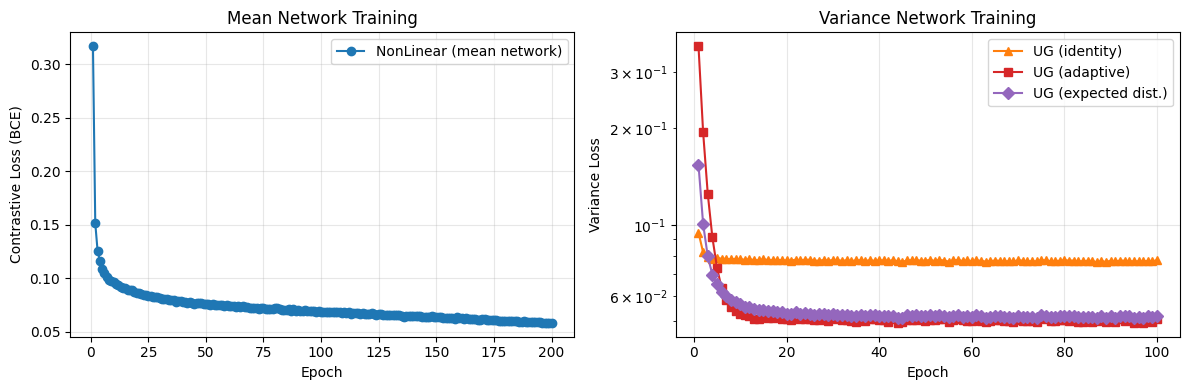

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: contrastive loss (shared mean network)
ax = axes[0]
ax.plot(range(1, len(loss_nl) + 1), loss_nl, "o-", label="NonLinear (mean network)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Contrastive Loss (BCE)")
ax.set_title("Mean Network Training")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: UncertainGen variance phase (both K forms)
ax = axes[1]
ax.plot(range(1, len(loss_ug_id) + 1), loss_ug_id, "^-", color="tab:orange",
        label="UG (identity)")
ax.plot(range(1, len(loss_ug_ad) + 1), loss_ug_ad, "s-", color="tab:red",
        label="UG (adaptive)")
ax.plot(range(1, len(loss_ug_ed) + 1), loss_ug_ed, "D-", color="tab:purple",
        label="UG (expected dist.)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Variance Loss")
ax.set_title("Variance Network Training")
ax.legend()
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:** The mean network converges to loss ~ 0.058, indicating good separation. For the variance phase, UG adaptive reaches 0.051 while UG identity plateaus at 0.077 -- confirming that the identity form's +1 offset dampens gradient signal to the variance network, resulting in a weaker fit.

## Embed Evaluation Data

In [16]:
# Embed test set with all models
emb_nl = model_nl.embed(test_seqs)
emb_lla = model_lla.embed(test_seqs)
emb_ug_id = model_ug_id.embed(test_seqs)
emb_ug_ad = model_ug_ad.embed(test_seqs)
emb_ug_ed = model_ug_ed.embed(test_seqs)

print(f"NonLinear:       mean {emb_nl.mean.shape}, probabilistic={emb_nl.is_probabilistic}")
print(f"LLA:             mean {emb_lla.mean.shape}, var {emb_lla.variance.shape}, probabilistic={emb_lla.is_probabilistic}")
print(f"UG (identity):   mean {emb_ug_id.mean.shape}, var {emb_ug_id.variance.shape}, probabilistic={emb_ug_id.is_probabilistic}")
print(f"UG (adaptive):   mean {emb_ug_ad.mean.shape}, var {emb_ug_ad.variance.shape}, probabilistic={emb_ug_ad.is_probabilistic}")
print(f"UG (expected dist.): mean {emb_ug_ed.mean.shape}, var {emb_ug_ed.variance.shape}, probabilistic={emb_ug_ed.is_probabilistic}")

NonLinear:       mean (6000, 256), probabilistic=False
LLA:             mean (6000, 256), var (6000, 256), probabilistic=True
UG (identity):   mean (6000, 256), var (6000, 256), probabilistic=True
UG (adaptive):   mean (6000, 256), var (6000, 256), probabilistic=True
UG (expected dist.): mean (6000, 256), var (6000, 256), probabilistic=True


### Variance Statistics & Signal-to-Noise Analysis

The cells below examine the variance estimates from each probabilistic model and whether they carry useful per-dimension information.

**Variance summary** (cell below): raw statistics of predicted variance. We expect UG adaptive to have the largest variances (its adaptive kernel allows variance to grow freely with no normalization penalty), UG identity to have small variances (the +1 offset in the identity form dampens gradient signal), and LLA to have small variances (post-hoc, not trained for this task).

**SNR diagnostic** (3x3 plot): For each model, three views:
1. **SNR histogram** -- signal-to-noise ratio per dimension: $\text{SNR}_d = \text{Var}(\mu_d) / E[\sigma^2_d]$. SNR > 1 means the embedding spread exceeds the uncertainty on that dimension -- the variance is informative. SNR < 1 means the uncertainty dominates the signal.
2. **Spread vs Uncertainty** -- scatter of per-dimension embedding variance vs mean predicted variance. Points above the red line (SNR < 1) are dimensions where uncertainty exceeds signal.
3. **Reweighting effect** -- ratio of Mahalanobis to Euclidean weight per dimension for intra-class pairs. This measures the adaptive form's reweighting: $w_d \propto 1/(\sigma^2_{i,d}+\sigma^2_{j,d})$. Flat at 1.0 means no reweighting; variation means variance is selectively up/downweighting dimensions. Note: for UG identity, which uses the identity form instead of adaptive Mahalanobis, this plot shows the adaptive reweighting for comparison only -- the actual identity form has a different effect (log penalty + damped distance, not pure reweighting).

In [17]:
for name, emb in [("UG (identity)", emb_ug_id), ("UG (adaptive)", emb_ug_ad), ("LLA", emb_lla), ("UG (expected dist.)", emb_ug_ed)]:
    v = emb.variance
    print(f"{name:15s}  mean={v.mean():.6f}, std={v.std():.6f}, min={v.min():.6f}, max={v.max():.6f}")

UG (identity)    mean=0.001952, std=0.001176, min=0.000000, max=0.011347
UG (adaptive)    mean=0.639932, std=0.217072, min=0.005399, max=1.996934
LLA              mean=0.001660, std=0.000526, min=0.000676, max=0.008541
UG (expected dist.)  mean=0.000031, std=0.000015, min=0.000002, max=0.000181


UG (identity) SNR: median=0.29, mean=557.95, min=0.00, max=43943.29
  SNR < 0.1: 27/256,  0.1-10: 220/256,  SNR > 10: 9/256

UG (adaptive) SNR: median=0.00, mean=0.19, min=0.00, max=13.00
  SNR < 0.1: 247/256,  0.1-10: 8/256,  SNR > 10: 1/256

LLA SNR: median=0.35, mean=13.55, min=0.00, max=845.76
  SNR < 0.1: 19/256,  0.1-10: 228/256,  SNR > 10: 9/256

UG (expected dist.) SNR: median=19.11, mean=678.75, min=0.00, max=46008.90
  SNR < 0.1: 2/256,  0.1-10: 45/256,  SNR > 10: 209/256



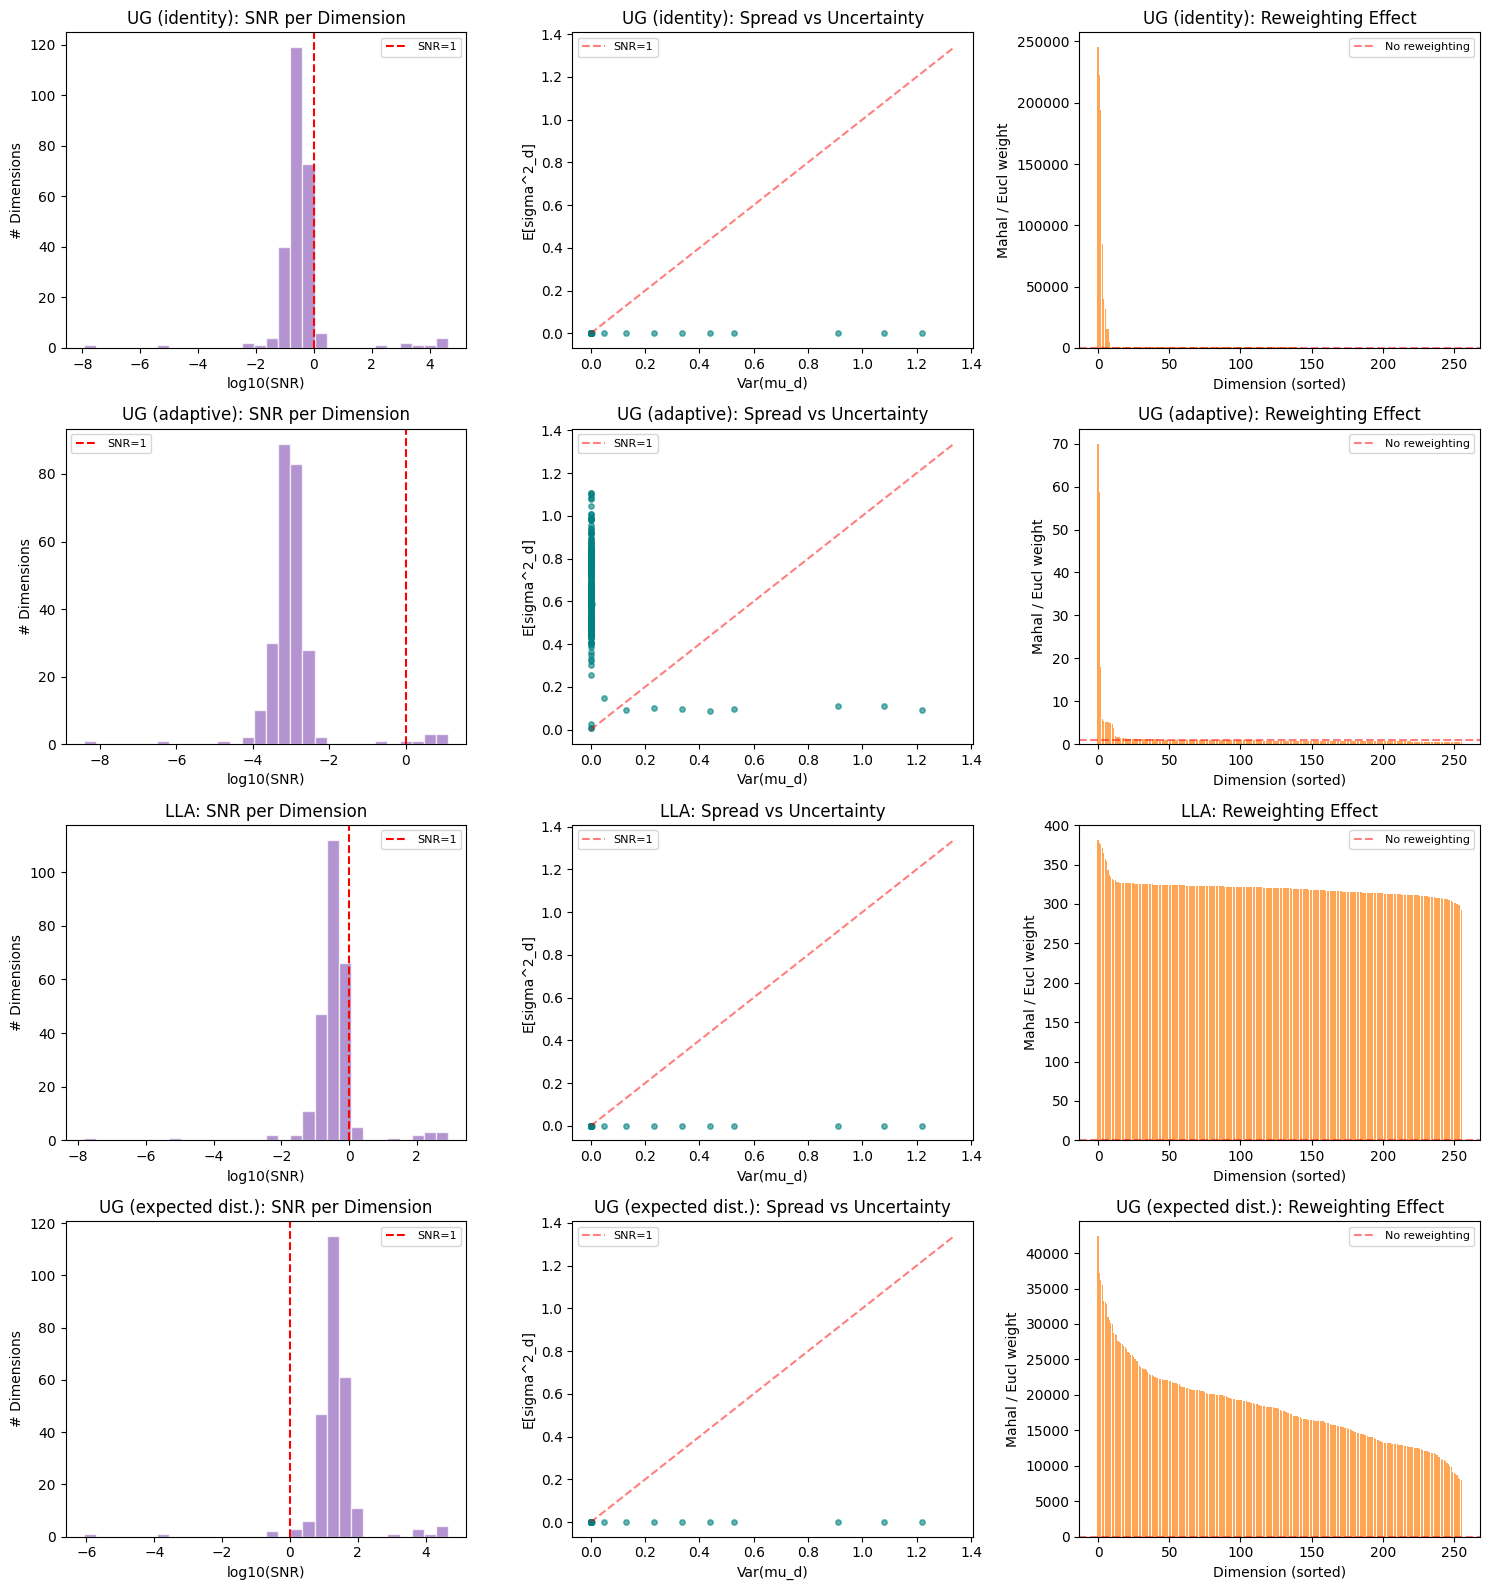

In [18]:
# --- Variance-to-distance scale diagnostic ---
prob_models = [
    ("UG (identity)", emb_ug_id),
    ("UG (adaptive)", emb_ug_ad),
    ("LLA", emb_lla),
    ("UG (expected dist.)", emb_ug_ed),
]

fig, axes = plt.subplots(len(prob_models), 3, figsize=(15, 4 * len(prob_models)))

for row, (name, emb) in enumerate(prob_models):
    mu = emb.mean
    var = emb.variance

    # Per-dimension SNR
    mean_spread = np.var(mu, axis=0)
    mean_var = np.mean(var, axis=0)
    snr = mean_spread / (mean_var + 1e-12)

    print(f"{name} SNR: median={np.median(snr):.2f}, mean={np.mean(snr):.2f}, "
          f"min={np.min(snr):.2f}, max={np.max(snr):.2f}")
    print(f"  SNR < 0.1: {(snr < 0.1).sum()}/{len(snr)},  "
          f"0.1-10: {((snr >= 0.1) & (snr <= 10)).sum()}/{len(snr)},  "
          f"SNR > 10: {(snr > 10).sum()}/{len(snr)}")

    # Intra-class Mahalanobis vs Euclidean
    rng = np.random.RandomState(SEED)
    intra_pairs = []
    for label in np.unique(test_labels):
        idxs = np.where(test_labels == label)[0]
        if len(idxs) >= 2:
            for _ in range(min(10, len(idxs) // 2)):
                i, j = rng.choice(idxs, size=2, replace=False)
                intra_pairs.append((i, j))
    intra_pairs = intra_pairs[:2000]
    ii, jj = zip(*intra_pairs)

    delta_sq = (mu[ii, :] - mu[jj, :]) ** 2
    sum_var = var[ii, :] + var[jj, :]
    mahal_per_dim = delta_sq / (sum_var + 1e-12)
    ratio = mahal_per_dim.mean(axis=0) / (delta_sq.mean(axis=0) + 1e-12)

    # Left: SNR histogram
    ax = axes[row, 0]
    ax.hist(np.log10(snr + 1e-12), bins=30, color="tab:purple", alpha=0.7, edgecolor="white")
    ax.axvline(0, ls="--", color="red", label="SNR=1")
    ax.set_xlabel("log10(SNR)")
    ax.set_ylabel("# Dimensions")
    ax.set_title(f"{name}: SNR per Dimension")
    ax.legend(fontsize=8)

    # Middle: spread vs uncertainty
    ax = axes[row, 1]
    ax.scatter(mean_spread, mean_var, s=15, alpha=0.6, color="teal")
    lim = max(mean_spread.max(), mean_var.max()) * 1.1
    ax.plot([0, lim], [0, lim], "r--", alpha=0.5, label="SNR=1")
    ax.set_xlabel("Var(mu_d)")
    ax.set_ylabel("E[sigma^2_d]")
    ax.set_title(f"{name}: Spread vs Uncertainty")
    ax.legend(fontsize=8)

    # Right: reweighting effect
    ax = axes[row, 2]
    ax.bar(range(len(ratio)), np.sort(ratio)[::-1], color="tab:orange", alpha=0.7)
    ax.axhline(1.0, ls="--", color="red", alpha=0.5, label="No reweighting")
    ax.set_xlabel("Dimension (sorted)")
    ax.set_ylabel("Mahal / Eucl weight")
    ax.set_title(f"{name}: Reweighting Effect")
    ax.legend(fontsize=8)

    print()

plt.tight_layout()
plt.show()

**Observations:**

- **UG adaptive** (adaptive Mahalanobis): has massive variance (mean=0.64) that dominates the signal -- 247/256 dimensions have SNR < 0.1. The adaptive Mahalanobis reweighting is extreme: variance completely overwhelms the embedding information on almost every dimension. Since this form has no normalization penalty, high variance uniformly inflates similarity.
- **UG identity** (identity form): has tiny variance (mean=0.002) due to the +1 dampening in the identity kernel. SNR is moderate (median=0.29). The identity form does not reweight dimensions like adaptive Mahalanobis -- instead, each nonzero variance adds a log-penalty offset and dampens the distance by dividing by $(\sigma^2_i+\sigma^2_j+1) \approx 1.004$. With variances this small, the effect is minimal.
- **LLA** (adaptive Mahalanobis, default): has similarly small variance (mean=0.002) with moderate SNR (median=0.35). Crucially, as shown in cell 10, the LLA variance is nearly constant across dimensions ($B \approx cI$), so the adaptive Mahalanobis collapses to a per-sample scalar -- no useful per-dimension reweighting, only a global similarity inflation for uncertain samples.
- **UG expected distance** (expected distance form): has the smallest variance of all models (mean=0.000031) but achieves by far the highest SNR (median=19.11, mean=678.75) with 209/256 dimensions having SNR > 10. The expected distance kernel computes $\mathbb{E}[\|z_i - z_j\|^2] = \|\mu_i - \mu_j\|^2 + \text{tr}(\Sigma_i + \Sigma_j)$, adding a small positive bias proportional to total uncertainty rather than reweighting per-dimension.

**Key takeaway:** Only UG adaptive has learned large enough variances to meaningfully affect the similarity computation, but its SNR is so low that the variance noise drowns out the embedding signal. UG identity's variances are too small to matter in either form. LLA's near-isotropic variance makes the adaptive Mahalanobis harmful (inflates similarity for uncertain samples). UG expected distance has tiny variances but the highest SNR of all models, meaning its variance is well-calibrated relative to the embedding signal -- the expected distance form may leverage this effectively.

## Clustering & Evaluation

### Similarity metrics

Each model uses a similarity function that matches its training loss structure. The scale $s$ is auto-calibrated (see below).

**Deterministic (NonLinear):**

$$\text{sim}(i, j) = \exp\!\bigl(-s\,\|\boldsymbol{\mu}_i - \boldsymbol{\mu}_j\|_2^2\bigr)$$

Matches the Bernoulli contrastive training loss $\log p = -s\,d^2$.

**Probabilistic -- adaptive form (UG adaptive, LLA):**

$$\text{sim}(i, j) = \exp\!\left(-s \sum_d \frac{(\mu_{i,d} - \mu_{j,d})^2}{\sigma^2_{i,d} + \sigma^2_{j,d}}\right)$$

Inverse-variance-weighted distance: high variance *shrinks* the distance on that dimension. There is no log-normalization term -- the adaptive kernel $K=\alpha(\Sigma_i+\Sigma_j)$ cancels the determinant, so there is **no penalty for being uncertain**. This matches the adaptive training loss (up to a constant $\frac{1}{2(1+\alpha)}$ absorbed by calibration).

**Probabilistic -- identity form (UG identity):**

$$\text{sim}(i, j) = \exp\!\left(-s \sum_d \left[\tfrac{1}{2}\log\!\bigl(\sigma^2_{i,d} + \sigma^2_{j,d} + 1\bigr) + \frac{(\mu_{i,d} - \mu_{j,d})^2}{2(\sigma^2_{i,d} + \sigma^2_{j,d} + 1)}\right]\right)$$

Includes a **log-normalization penalty** (increases distance when variance is nonzero) and a **+1 offset** in the denominator (dampens the effect of small variances). When $\sigma^2 = 0$, this reduces to $\exp(-\tfrac{s}{2}\|\delta\|^2)$, equivalent to deterministic L2. This matches the $K=I$ training loss exactly.

| Model | Similarity form | Variance effect |
|---|---|---|
| **NonLinear** | Deterministic L2 | -- (no variance) |
| **UG (adaptive)** | Adaptive Mahalanobis | Divides distance (inflates similarity) |
| **UG (identity)** | Identity form | Log penalty + damped distance (deflates similarity) |
| **LLA** | Adaptive Mahalanobis (default) | Divides distance (inflates similarity) |

### Auto-calibration of scale

The scale $s$ is chosen so that the median intra-class similarity to class centers equals 0.5:

$$s = \frac{\ln 2}{\text{median}(\text{raw distances to class centers})}$$

where "raw distance" uses the same formula as the model's similarity (adaptive Mahalanobis for UG adaptive/LLA, identity form for UG identity, squared Euclidean for NonLinear). This ensures the calibrated scale matches each model's distance metric.

### K-Medoids clustering

Clustering on the precomputed distance matrix $D_{ij} = 1 - \text{sim}(i, j)$. Number of clusters $k$ is estimated from connected components in the thresholded similarity graph ($\text{sim} \ge \tau$). Clusters smaller than `MIN_BIN_SIZE` are discarded (label $= -1$).

| Method | Algorithm | Complexity | Notes |
|--------|-----------|------------|-------|
| `"alternate"` | Assign-update (Voronoi iteration) | $O(n \cdot k)$ per iter | Fast heuristic |
| `"pam"` | Partitioning Around Medoids | $O(n^2 \cdot k)$ per iter | Exact but slow for $n > 2000$ |

### Evaluation

Per-class F1 scores after Hungarian label alignment. We report the number of classes exceeding F1 thresholds at 0.3, 0.5, 0.7.

In [19]:
METRIC = "l2"
MIN_BIN_SIZE = 5
KMEDOID_METHOD = "alternate"  # "alternate" = fast O(nk); "pam" = exact O(n^2*k)
train_labels_num = np.array([lab2id[l] for l in train_labels])

# --- UncertainGen identity (probabilistic, k_form="identity") ---
train_emb_ug_id = model_ug_id.embed(train_seqs)
pv_ug_id, scale_ug_id = compute_class_center_medium_similarity(
    train_emb_ug_id.point_estimate, train_labels_num, metric=METRIC,
    variances=train_emb_ug_id.variance, k_form="identity", alpha=ALPHA,
)
threshold_ug_id = pv_ug_id[-3]
print(f"UG (identity) threshold: {threshold_ug_id:.4f}, scale: {scale_ug_id:.6f}")

kmed_ug_id = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                               scale=scale_ug_id, method=KMEDOID_METHOD,
                               k_form="identity", alpha=ALPHA)
pred_ug_id = kmed_ug_id.fit_predict(emb_ug_id, min_similarity=threshold_ug_id)

r_ug_id = count_high_quality_clusters(test_labels, pred_ug_id)
assigned_ug_id = (pred_ug_id != -1).sum()
k_ug_id = len(set(pred_ug_id[pred_ug_id != -1].tolist())) if assigned_ug_id > 0 else 0

print(f"\n=== KMedoid (UncertainGen identity, alpha={ALPHA}) ===")
print(f"Clusters found: {k_ug_id} (true: {n_species})")
print(f"Coverage: {assigned_ug_id}/{len(pred_ug_id)} ({assigned_ug_id/len(pred_ug_id):.0%})")
print(f"F1>0.3: {r_ug_id['counts'][2]}, F1>0.5: {r_ug_id['counts'][4]}, F1>0.7: {r_ug_id['counts'][6]}")

# --- UncertainGen adaptive (probabilistic, k_form="adaptive") ---
train_emb_ug_ad = model_ug_ad.embed(train_seqs)
pv_ug_ad, scale_ug_ad = compute_class_center_medium_similarity(
    train_emb_ug_ad.point_estimate, train_labels_num, metric=METRIC,
    variances=train_emb_ug_ad.variance, k_form="adaptive",
)
threshold_ug_ad = pv_ug_ad[-3]
print(f"\nUG (adaptive) threshold: {threshold_ug_ad:.4f}, scale: {scale_ug_ad:.6f}")

kmed_ug_ad = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                               scale=scale_ug_ad, method=KMEDOID_METHOD,
                               k_form="adaptive")
pred_ug_ad = kmed_ug_ad.fit_predict(emb_ug_ad, min_similarity=threshold_ug_ad)

r_ug_ad = count_high_quality_clusters(test_labels, pred_ug_ad)
assigned_ug_ad = (pred_ug_ad != -1).sum()
k_ug_ad = len(set(pred_ug_ad[pred_ug_ad != -1].tolist())) if assigned_ug_ad > 0 else 0

print(f"\n=== KMedoid (UncertainGen adaptive, alpha={ALPHA}) ===")
print(f"Clusters found: {k_ug_ad} (true: {n_species})")
print(f"Coverage: {assigned_ug_ad}/{len(pred_ug_ad)} ({assigned_ug_ad/len(pred_ug_ad):.0%})")
print(f"F1>0.3: {r_ug_ad['counts'][2]}, F1>0.5: {r_ug_ad['counts'][4]}, F1>0.7: {r_ug_ad['counts'][6]}")

# --- LLA (probabilistic, post-hoc on NonLinear) ---
train_emb_lla = model_lla.embed(train_seqs)
pv_lla, scale_lla = compute_class_center_medium_similarity(
    train_emb_lla.point_estimate, train_labels_num, metric=METRIC,
    variances=train_emb_lla.variance,
)
threshold_lla = pv_lla[-3]
print(f"\nLLA threshold: {threshold_lla:.4f}, scale: {scale_lla:.6f}")

kmed_lla = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE, scale=scale_lla, method=KMEDOID_METHOD)
pred_lla = kmed_lla.fit_predict(emb_lla, min_similarity=threshold_lla)

r_lla = count_high_quality_clusters(test_labels, pred_lla)
assigned_lla = (pred_lla != -1).sum()
k_lla = len(set(pred_lla[pred_lla != -1].tolist())) if assigned_lla > 0 else 0

print(f"\n=== KMedoid (LLA, probabilistic) ===")
print(f"Clusters found: {k_lla} (true: {n_species})")
print(f"Coverage: {assigned_lla}/{len(pred_lla)} ({assigned_lla/len(pred_lla):.0%})")
print(f"F1>0.3: {r_lla['counts'][2]}, F1>0.5: {r_lla['counts'][4]}, F1>0.7: {r_lla['counts'][6]}")


# --- UncertainGen expected distance (probabilistic, k_form="expected_distance") ---
train_emb_ug_ed = model_ug_ed.embed(train_seqs)
pv_ug_ed, scale_ug_ed = compute_class_center_medium_similarity(
    train_emb_ug_ed.point_estimate, train_labels_num, metric=METRIC,
    variances=train_emb_ug_ed.variance, k_form="expected_distance",
)
threshold_ug_ed = pv_ug_ed[-3]
print(f"UG (expected dist.) threshold: {threshold_ug_ed:.4f}, scale: {scale_ug_ed:.6f}")

kmed_ug_ed = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                               scale=scale_ug_ed, method=KMEDOID_METHOD,
                               k_form="expected_distance")
pred_ug_ed = kmed_ug_ed.fit_predict(emb_ug_ed, min_similarity=threshold_ug_ed)

r_ug_ed = count_high_quality_clusters(test_labels, pred_ug_ed)
assigned_ug_ed = (pred_ug_ed != -1).sum()
k_ug_ed = len(set(pred_ug_ed[pred_ug_ed != -1].tolist())) if assigned_ug_ed > 0 else 0

print(f"\n=== KMedoid (UncertainGen expected distance, alpha={ALPHA}) ===")
print(f"Clusters found: {k_ug_ed} (true: {n_species})")
print(f"Coverage: {assigned_ug_ed}/{len(pred_ug_ed)} ({assigned_ug_ed/len(pred_ug_ed):.0%})")
print(f"F1>0.3: {r_ug_ed['counts'][2]}, F1>0.5: {r_ug_ed['counts'][4]}, F1>0.7: {r_ug_ed['counts'][6]}")

# --- NonLinear (deterministic) ---
train_emb_nl = model_nl.embed(train_seqs)
pv_nl, scale_nl = compute_class_center_medium_similarity(
    train_emb_nl.point_estimate, train_labels_num, metric=METRIC,
)
threshold_nl = pv_nl[-3]
print(f"\nNonLinear threshold: {threshold_nl:.4f}, scale: {scale_nl:.6f}")

kmed_nl = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE, scale=scale_nl, method=KMEDOID_METHOD)
pred_nl = kmed_nl.fit_predict(emb_nl, min_similarity=threshold_nl)

r_nl = count_high_quality_clusters(test_labels, pred_nl)
assigned_nl = (pred_nl != -1).sum()
k_nl = len(set(pred_nl[pred_nl != -1].tolist())) if assigned_nl > 0 else 0

print(f"\n=== KMedoid (NonLinear, deterministic, loss={LOSS_NAME}, scale={LOSS_SCALE}) ===")
print(f"Clusters found: {k_nl} (true: {n_species})")
print(f"Coverage: {assigned_nl}/{len(pred_nl)} ({assigned_nl/len(pred_nl):.0%})")
print(f"F1>0.3: {r_nl['counts'][2]}, F1>0.5: {r_nl['counts'][4]}, F1>0.7: {r_nl['counts'][6]}")

Auto-calibrated scale: 1.192968 (median raw distance: 0.5810)
Percentile values: [0.2528558671474457, 0.29359570145606995, 0.34250274300575256, 0.4220806658267975, 0.5000014305114746, 0.5700944662094116, 0.6304619908332825, 0.6834898591041565, 0.7340532541275024]
UG (identity) threshold: 0.6305, scale: 1.192968


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [01:24<00:00]


KMedoids: k_est=42, n=6000, method=alternate

=== KMedoid (UncertainGen identity, alpha=1.0) ===
Clusters found: 42 (true: 200)
Coverage: 6000/6000 (100%)
F1>0.3: 17, F1>0.5: 3, F1>0.7: 1
Auto-calibrated scale: 0.639070 (median raw distance: 1.0846)
Percentile values: [0.1219196617603302, 0.22511707246303558, 0.3233273923397064, 0.40972086787223816, 0.5000096559524536, 0.5794991254806519, 0.6569945216178894, 0.7303972840309143, 0.8053097128868103]

UG (adaptive) threshold: 0.6570, scale: 0.639070


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [00:31<00:00]


KMedoids: k_est=127, n=6000, method=alternate

=== KMedoid (UncertainGen adaptive, alpha=1.0) ===
Clusters found: 125 (true: 200)
Coverage: 5992/6000 (100%)
F1>0.3: 56, F1>0.5: 32, F1>0.7: 15
Auto-calibrated scale: 0.008693 (median raw distance: 79.7371)
Percentile values: [0.10202571749687195, 0.2005641609430313, 0.3002845048904419, 0.4026319980621338, 0.5000460743904114, 0.5899897217750549, 0.6735953092575073, 0.7465170621871948, 0.8236982226371765]

LLA threshold: 0.6736, scale: 0.008693


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [00:31<00:00]


KMedoids: k_est=118, n=6000, method=alternate

=== KMedoid (LLA, probabilistic) ===
Clusters found: 93 (true: 200)
Coverage: 5951/6000 (99%)
F1>0.3: 43, F1>0.5: 17, F1>0.7: 7
Auto-calibrated scale: 2.803843 (median raw distance: 0.2472)
Percentile values: [0.13492640852928162, 0.23770548403263092, 0.3302474021911621, 0.4155106246471405, 0.5000245571136475, 0.5803443193435669, 0.6511720418930054, 0.7187567949295044, 0.7872401475906372]
UG (expected dist.) threshold: 0.6512, scale: 2.803843


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [00:26<00:00]


KMedoids: k_est=119, n=6000, method=alternate

=== KMedoid (UncertainGen expected distance, alpha=1.0) ===
Clusters found: 118 (true: 200)
Coverage: 5997/6000 (100%)
F1>0.3: 61, F1>0.5: 32, F1>0.7: 10
Auto-calibrated scale: 2.997387 (median raw distance: 0.2313)
Percentile values: [0.12450093482649371, 0.2280380439922255, 0.3230909830239522, 0.41105853727277486, 0.5000850313731194, 0.5835276401654267, 0.6581730939166871, 0.73087140859097, 0.8041553183219755]

NonLinear threshold: 0.6582, scale: 2.997387
KMedoids: k_est=123, n=6000, method=alternate

=== KMedoid (NonLinear, deterministic, loss=bern, scale=1.0) ===
Clusters found: 121 (true: 200)
Coverage: 5993/6000 (100%)
F1>0.3: 68, F1>0.5: 40, F1>0.7: 18


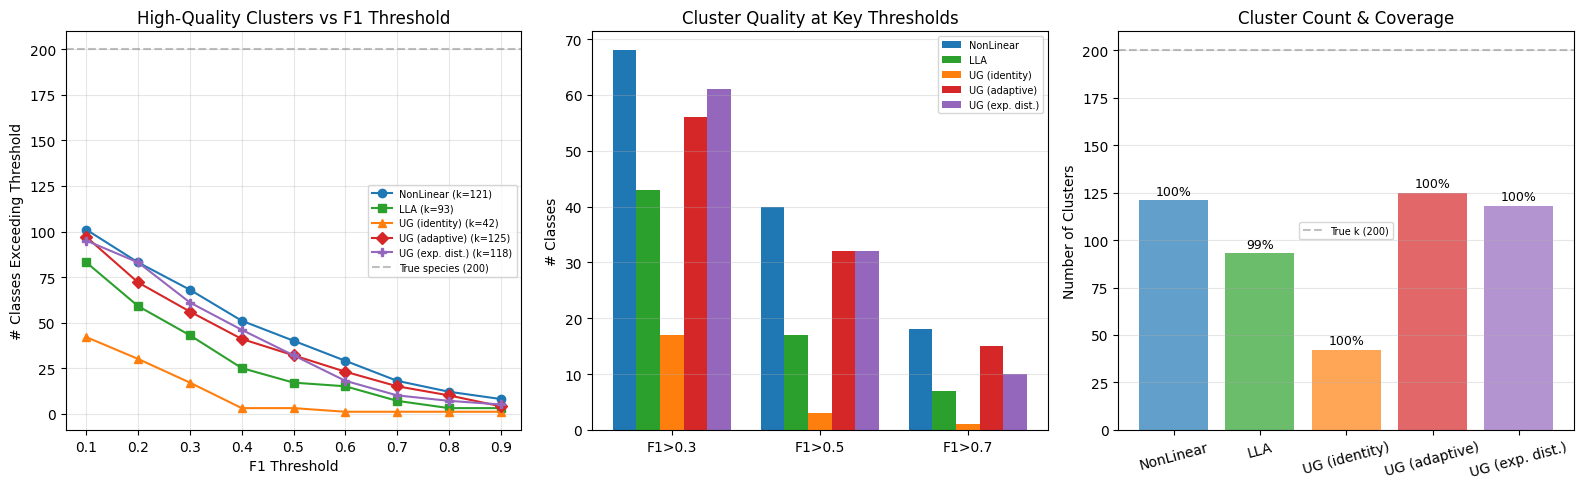

In [20]:
# --- Results comparison plot ---
thresholds = r_nl["thresholds"]
all_results = [
    ("NonLinear",      r_nl,     k_nl,     assigned_nl,     pred_nl,     "tab:blue"),
    ("LLA",            r_lla,    k_lla,    assigned_lla,    pred_lla,    "tab:green"),
    ("UG (identity)",  r_ug_id,  k_ug_id,  assigned_ug_id,  pred_ug_id,  "tab:orange"),
    ("UG (adaptive)",  r_ug_ad,  k_ug_ad,  assigned_ug_ad,  pred_ug_ad,  "tab:red"),
    ("UG (exp. dist.)", r_ug_ed,  k_ug_ed,  assigned_ug_ed,  pred_ug_ed,  "tab:purple"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: F1 threshold curve
ax = axes[0]
markers = ["o", "s", "^", "D", "P", "v"]
for (name, r, k, _, _, color), marker in zip(all_results, markers):
    ax.plot(thresholds, r["counts"], f"{marker}-", label=f"{name} (k={k})", color=color)
ax.axhline(n_species, ls="--", color="gray", alpha=0.5, label=f"True species ({n_species})")
ax.set_xlabel("F1 Threshold")
ax.set_ylabel("# Classes Exceeding Threshold")
ax.set_title("High-Quality Clusters vs F1 Threshold")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Middle: grouped bar chart at key thresholds
ax = axes[1]
key_thresholds = [0.3, 0.5, 0.7]
key_idx = [thresholds.index(t) for t in key_thresholds]
n_models = len(all_results)
x = np.arange(len(key_thresholds))
w = 0.8 / n_models
for i, (name, r, _, _, _, color) in enumerate(all_results):
    offset = (i - n_models / 2 + 0.5) * w
    ax.bar(x + offset, [r["counts"][j] for j in key_idx], w, label=name, color=color)
ax.set_xticks(x)
ax.set_xticklabels([f"F1>{t}" for t in key_thresholds])
ax.set_ylabel("# Classes")
ax.set_title("Cluster Quality at Key Thresholds")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3, axis="y")

# Right: k estimation and coverage
ax = axes[2]
model_names = [r[0] for r in all_results]
k_vals = [r[2] for r in all_results]
coverages = [r[3] / len(r[4]) for r in all_results]
colors = [r[5] for r in all_results]

ax.bar(model_names, k_vals, color=colors, alpha=0.7)
ax.axhline(n_species, ls="--", color="gray", alpha=0.5, label=f"True k ({n_species})")
ax.set_ylabel("Number of Clusters")
ax.set_title("Cluster Count & Coverage")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3, axis="y")
ax.tick_params(axis="x", rotation=15)

for i, (name, k, cov) in enumerate(zip(model_names, k_vals, coverages)):
    ax.text(i, k + 3, f"{cov:.0%}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

**Clustering results:**

| Model | Similarity | k_est | F1>0.3 | F1>0.5 | F1>0.7 | Scale |
|---|---|---|---|---|---|---|
| **NonLinear** | Deterministic L2 | 121 | **68** | **40** | **18** | 2.997 |
| **UG (adaptive)** | Adaptive Mahalanobis | 125 | 56 | 32 | 15 | 0.639 |
| **LLA** | Adaptive Mahalanobis | 93 | 43 | 17 | 7 | 0.009 |
| **UG (expected dist.)** | Expected distance | 118 | 61 | 32 | 10 | 2.804 |
| **UG (identity)** | Identity form | 42 | 17 | 3 | 1 | 1.193 |

**Key findings:**

1. **Deterministic NonLinear is the best.** All three probabilistic models perform worse than the deterministic baseline, despite sharing the same mean embeddings. The variance is hurting, not helping.
2. **UG adaptive** (adaptive Mahalanobis) is closest to NonLinear -- its per-dimension reweighting has some value, but the very low SNR (247/256 dims with SNR < 0.1) means variance noise still degrades performance. The lack of normalization penalty inflates similarity for uncertain pairs.
3. **UG expected distance** matches UG adaptive on F1>0.5 (both 32) and is second-best on F1>0.3 (61 vs 68). Despite having tiny variances, its high SNR means the expected distance bias $\text{tr}(\Sigma_i + \Sigma_j)$ adds a meaningful, well-calibrated penalty that slightly penalizes uncertain pairs without distorting the distance structure.
4. **LLA** (adaptive Mahalanobis) dramatically underperforms (F1>0.5: 17 vs 40) because its near-isotropic variance collapses the adaptive Mahalanobis to a per-sample scalar that systematically inflates similarity for uncertain points (see cell 11).
5. **UG identity** (identity form) is worst ($k=42$, F1>0.5=3). The identity form's log-normalization $\sum_d \frac{1}{2}\log(\sigma^2_i+\sigma^2_j+1)$ adds a near-constant offset to every pair (since variances are uniformly tiny at ~0.002), compressing the inter/intra distance ratio and degrading $k$-estimation.
6. **Auto-calibrated scales** vary by 300x (0.009 to 2.997), reflecting vastly different raw distance distributions. LLA's scale of 0.009 indicates its adaptive Mahalanobis distances are ~300x larger than Euclidean, consistent with dividing by very small variances.

## Cluster Visualization (t-SNE)

2D t-SNE projection of the test embeddings. All models share the same mean network, so a single t-SNE is computed once and reused. Points are colored by true species label (top-left) or predicted cluster (others). Gray = unassigned ($-1$).

Computing t-SNE projection...
t-SNE done: (6000, 2)


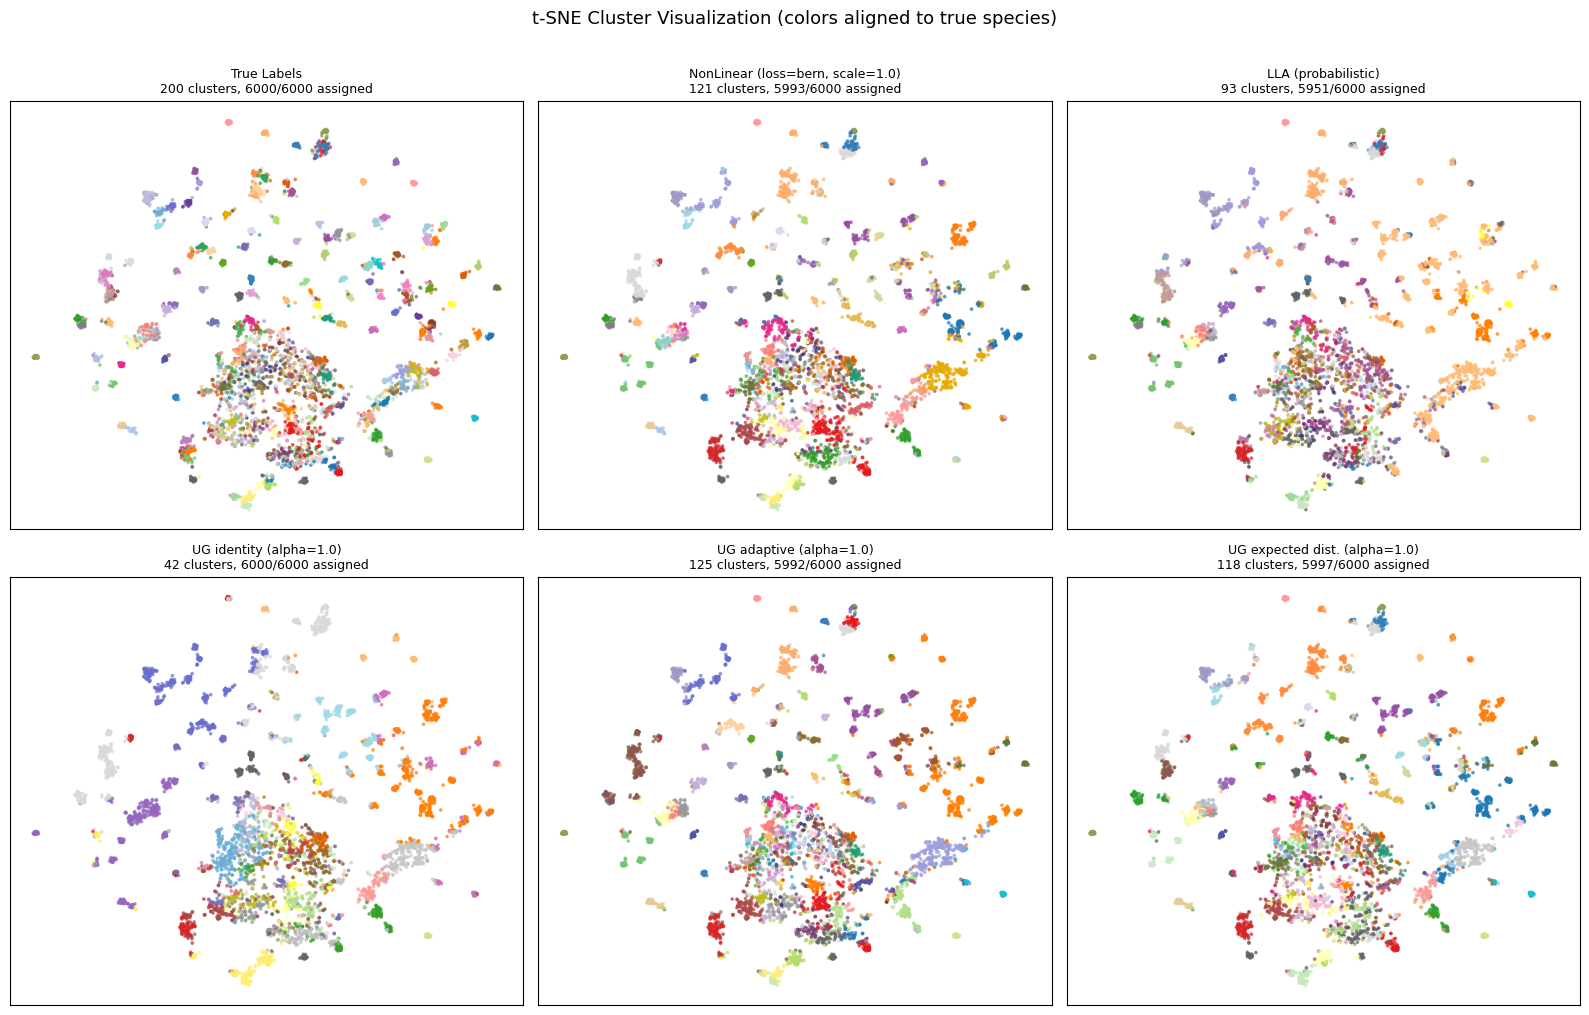

In [21]:
from sklearn.manifold import TSNE

# Compute t-SNE once (all models share the same mean embeddings)
print("Computing t-SNE projection...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
coords = tsne.fit_transform(emb_nl.mean)
print(f"t-SNE done: {coords.shape}")

# Build a fixed color map from true labels so colors are comparable across subplots.
# Predicted clusters are aligned to true labels via Hungarian algorithm before coloring.
point_size = 3
point_alpha = 0.6

# Assign each true species a unique color (cycle through a large qualitative palette)
true_unique = np.unique(test_labels)
n_true = len(true_unique)
# Use a combination of colormaps to get enough distinct colors for 200 species
base_colors = np.vstack([
    plt.cm.tab20(np.linspace(0, 1, 20)),
    plt.cm.tab20b(np.linspace(0, 1, 20)),
    plt.cm.tab20c(np.linspace(0, 1, 20)),
    plt.cm.Set1(np.linspace(0, 1, 9)),
    plt.cm.Set3(np.linspace(0, 1, 12)),
    plt.cm.Dark2(np.linspace(0, 1, 8)),
    plt.cm.Paired(np.linspace(0, 1, 12)),
])
# Tile if needed and select n_true colors
species_colors = np.tile(base_colors, (max(1, n_true // len(base_colors) + 1), 1))[:n_true]
true_label_to_color = {lab: species_colors[i] for i, lab in enumerate(true_unique)}

def plot_clusters_aligned(ax, coords, labels, title, alignment=None):
    """Plot 2D scatter with colors aligned to true species labels.
    
    For true labels: color directly by species.
    For predicted labels: use alignment dict (pred -> true) to map colors.
    Unassigned (-1) points are gray.
    """
    mask_assigned = labels != -1
    mask_unassigned = ~mask_assigned

    if mask_unassigned.any():
        ax.scatter(coords[mask_unassigned, 0], coords[mask_unassigned, 1],
                   c="lightgray", s=point_size, alpha=0.3, rasterized=True)

    if mask_assigned.any():
        if alignment is not None:
            # Map predicted labels to true labels, then to colors
            mapped = np.array([alignment.get(l, -1) for l in labels[mask_assigned]])
            c = np.array([true_label_to_color.get(m, [0.7, 0.7, 0.7, 1.0])
                          for m in mapped])
        else:
            # True labels: direct color lookup
            c = np.array([true_label_to_color[l] for l in labels[mask_assigned]])
        ax.scatter(coords[mask_assigned, 0], coords[mask_assigned, 1],
                   c=c, s=point_size, alpha=point_alpha, rasterized=True)

    n_clusters = len(np.unique(labels[mask_assigned])) if mask_assigned.any() else 0
    n_assigned = int(mask_assigned.sum())
    ax.set_title(f"{title}\n{n_clusters} clusters, {n_assigned}/{len(labels)} assigned", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

# Compute Hungarian alignments for each model's predictions
def get_alignment(true_labels, pred_labels):
    mask = pred_labels != -1
    if mask.sum() < 2:
        return {}
    return align_labels_via_hungarian_algorithm(true_labels[mask], pred_labels[mask])

align_nl_tsne = get_alignment(test_labels, pred_nl)
align_lla_tsne = get_alignment(test_labels, pred_lla)
align_ug_id_tsne = get_alignment(test_labels, pred_ug_id)
align_ug_ad_tsne = get_alignment(test_labels, pred_ug_ad)
align_ug_ed_tsne = get_alignment(test_labels, pred_ug_ed)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plot_clusters_aligned(axes[0, 0], coords, test_labels, "True Labels")
plot_clusters_aligned(axes[0, 1], coords, pred_nl,
                      f"NonLinear (loss={LOSS_NAME}, scale={LOSS_SCALE})",
                      alignment=align_nl_tsne)
plot_clusters_aligned(axes[0, 2], coords, pred_lla, "LLA (probabilistic)",
                      alignment=align_lla_tsne)
plot_clusters_aligned(axes[1, 0], coords, pred_ug_id, f"UG identity (alpha={ALPHA})",
                      alignment=align_ug_id_tsne)
plot_clusters_aligned(axes[1, 1], coords, pred_ug_ad, f"UG adaptive (alpha={ALPHA})",
                      alignment=align_ug_ad_tsne)
plot_clusters_aligned(axes[1, 2], coords, pred_ug_ed, f"UG expected dist. (alpha={ALPHA})",
                      alignment=align_ug_ed_tsne)

plt.suptitle("t-SNE Cluster Visualization (colors aligned to true species)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Uncertainty Heatmap (t-SNE)

Same t-SNE coordinates as above, but colored by $\log_{10}(\text{mean variance})$ per sample using a red (high) to green (low) colormap. This shows the spatial distribution of uncertainty.

**What to look for:** If uncertainty is useful, high-variance points should concentrate at cluster boundaries or in ambiguous regions (between clusters). If instead high-variance points are scattered uniformly, the uncertainty is not spatially informative.

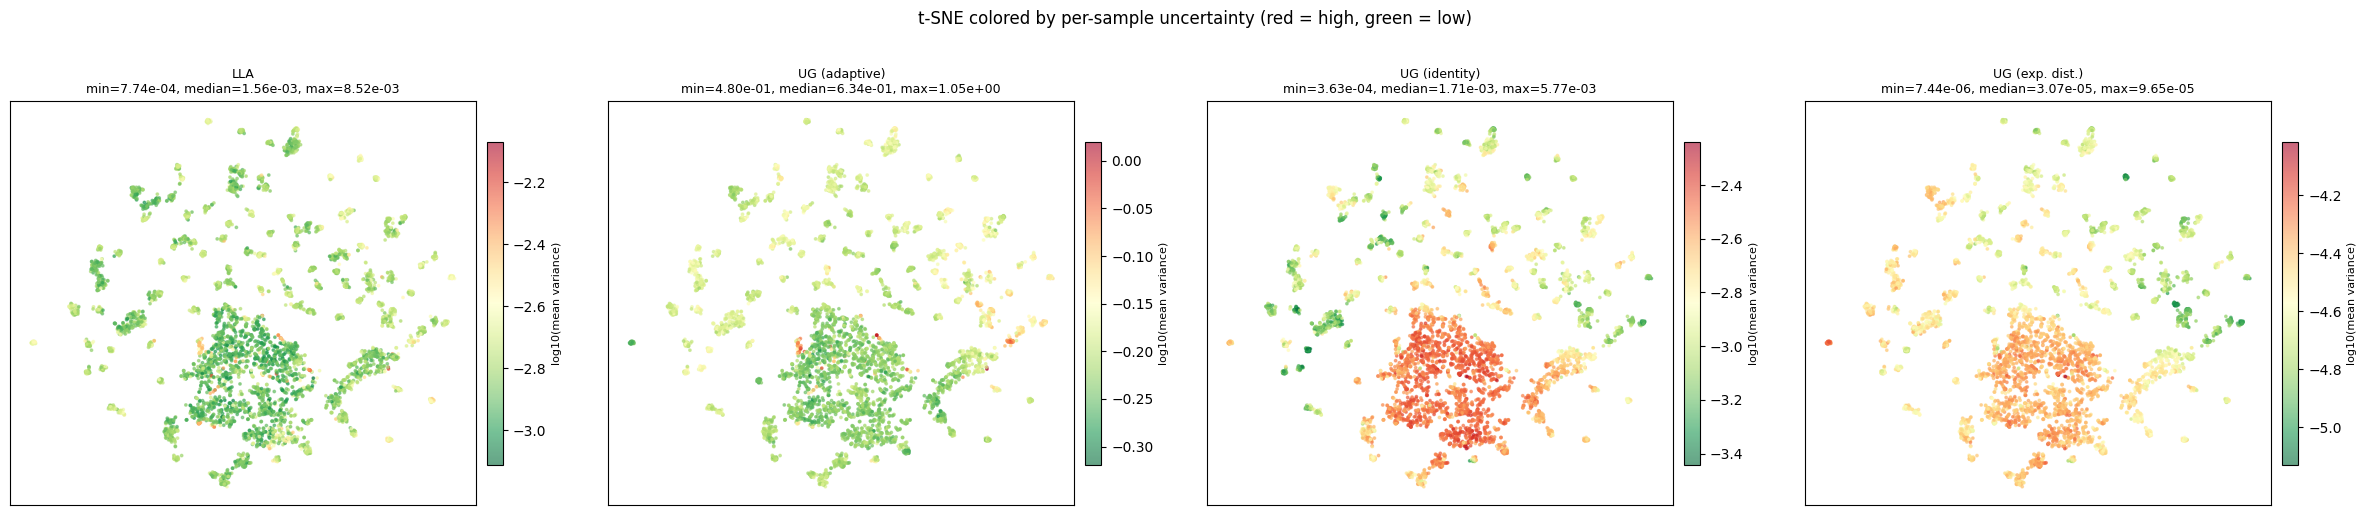

In [22]:
# --- t-SNE colored by per-sample uncertainty (mean variance) ---
# Same t-SNE coordinates as above, but color = total uncertainty per sample.
# This shows the spatial distribution of model confidence.

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

unc_models = [
    ("LLA",           emb_lla.variance.mean(axis=1),   "tab:green"),
    ("UG (adaptive)", emb_ug_ad.variance.mean(axis=1), "tab:red"),
    ("UG (identity)", emb_ug_id.variance.mean(axis=1), "tab:orange"),
    ("UG (exp. dist.)", emb_ug_ed.variance.mean(axis=1), "tab:purple"),
]

for ax, (name, unc, _) in zip(axes, unc_models):
    # Log-scale for better contrast (variances can span orders of magnitude)
    log_unc = np.log10(unc + 1e-12)
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=log_unc, s=3, alpha=0.6,
                    cmap="RdYlGn_r", rasterized=True)
    cb = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label("log10(mean variance)", fontsize=8)
    ax.set_title(f"{name}\nmin={unc.min():.2e}, median={np.median(unc):.2e}, max={unc.max():.2e}",
                 fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("t-SNE colored by per-sample uncertainty (red = high, green = low)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### LLA Diagnostic: Probabilistic vs Deterministic Clustering

Since LLA is a post-hoc method applied to the NonLinear embeddings, we can isolate the effect of LLA's variance by comparing:
- **LLA probabilistic**: Mahalanobis similarity using LLA's variance estimates
- **LLA deterministic**: plain L2 similarity on the same mean embeddings (identical to NonLinear)

If LLA's variance helps, probabilistic should outperform deterministic. If it hurts, we confirm that the Mahalanobis reweighting is actively harmful for LLA.

In [23]:
# --- Diagnostic: Does LLA variance help or hurt clustering? ---
# Compare LLA probabilistic (Mahalanobis) vs deterministic (L2) clustering.
# Both use the same mean embeddings; only the similarity function differs.

print("=== LLA: Probabilistic vs Deterministic ===\n")

# Deterministic: use L2 on LLA means (same as NonLinear embeddings)
pv_lla_det, scale_lla_det = compute_class_center_medium_similarity(
    train_emb_lla.point_estimate, train_labels_num, metric=METRIC,
)
threshold_lla_det = pv_lla_det[-3]

kmed_lla_det = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                                 scale=scale_lla_det, method=KMEDOID_METHOD)
# Create a deterministic-only embedding result (no variance)
emb_lla_det = EmbeddingResult(mean=emb_lla.mean)
pred_lla_det = kmed_lla_det.fit_predict(emb_lla_det, min_similarity=threshold_lla_det)

r_lla_det = count_high_quality_clusters(test_labels, pred_lla_det)
assigned_lla_det = (pred_lla_det != -1).sum()
k_lla_det = len(set(pred_lla_det[pred_lla_det != -1].tolist())) if assigned_lla_det > 0 else 0

print(f"\nLLA (deterministic L2):   k={k_lla_det}, F1>0.3={r_lla_det['counts'][2]}, "
      f"F1>0.5={r_lla_det['counts'][4]}, F1>0.7={r_lla_det['counts'][6]}")
print(f"LLA (probabilistic):      k={k_lla}, F1>0.3={r_lla['counts'][2]}, "
      f"F1>0.5={r_lla['counts'][4]}, F1>0.7={r_lla['counts'][6]}")
print(f"NonLinear (deterministic): k={k_nl}, F1>0.3={r_nl['counts'][2]}, "
      f"F1>0.5={r_nl['counts'][4]}, F1>0.7={r_nl['counts'][6]}")

if r_lla_det['counts'][4] > r_lla['counts'][4]:
    print("\n-> Mahalanobis reweighting HURTS LLA clustering. Variance is not well-calibrated.")
elif r_lla_det['counts'][4] < r_lla['counts'][4]:
    print("\n-> Mahalanobis reweighting HELPS LLA clustering.")
else:
    print("\n-> Mahalanobis reweighting has no effect at F1>0.5.")

=== LLA: Probabilistic vs Deterministic ===

Auto-calibrated scale: 2.997387 (median raw distance: 0.2313)
Percentile values: [0.12450093482649371, 0.2280380439922255, 0.3230909830239522, 0.41105853727277486, 0.5000850313731194, 0.5835276401654267, 0.6581730939166871, 0.73087140859097, 0.8041553183219755]
KMedoids: k_est=123, n=6000, method=alternate

LLA (deterministic L2):   k=121, F1>0.3=68, F1>0.5=40, F1>0.7=18
LLA (probabilistic):      k=93, F1>0.3=43, F1>0.5=17, F1>0.7=7
NonLinear (deterministic): k=121, F1>0.3=68, F1>0.5=40, F1>0.7=18

-> Mahalanobis reweighting HURTS LLA clustering. Variance is not well-calibrated.


**Result:** LLA deterministic (F1>0.5=40) exactly matches NonLinear, while LLA probabilistic drops to F1>0.5=17. The adaptive Mahalanobis reweighting cuts performance by more than half. This confirms the variance is actively harmful when used in the similarity function -- the near-isotropic B factor (cell 10) means the adaptive Mahalanobis collapses to per-sample reweighting that inflates similarity for uncertain points, with no normalization penalty to counteract it.

## Selective Prediction

If variance is harmful for the similarity function, can it still be useful as a **confidence signal**? In selective prediction, we keep each model's own clustering but discard the most uncertain samples. At each coverage level (100% -> 10%), we keep only the most confident samples and measure F1 and accuracy on the retained subset.

**What to expect:** If variance is a good confidence signal, F1 and accuracy should improve as we discard uncertain samples (the retained subset is "easier"). If variance is uninformative, the curves should be flat (similar to random rejection). If variance is anti-correlated with correctness, the curves should decrease.

**Caveat:** Each model uses its own clustering (which varies in quality), so differences in the curves reflect both variance quality AND clustering quality. The decoupled experiment below isolates the variance signal.

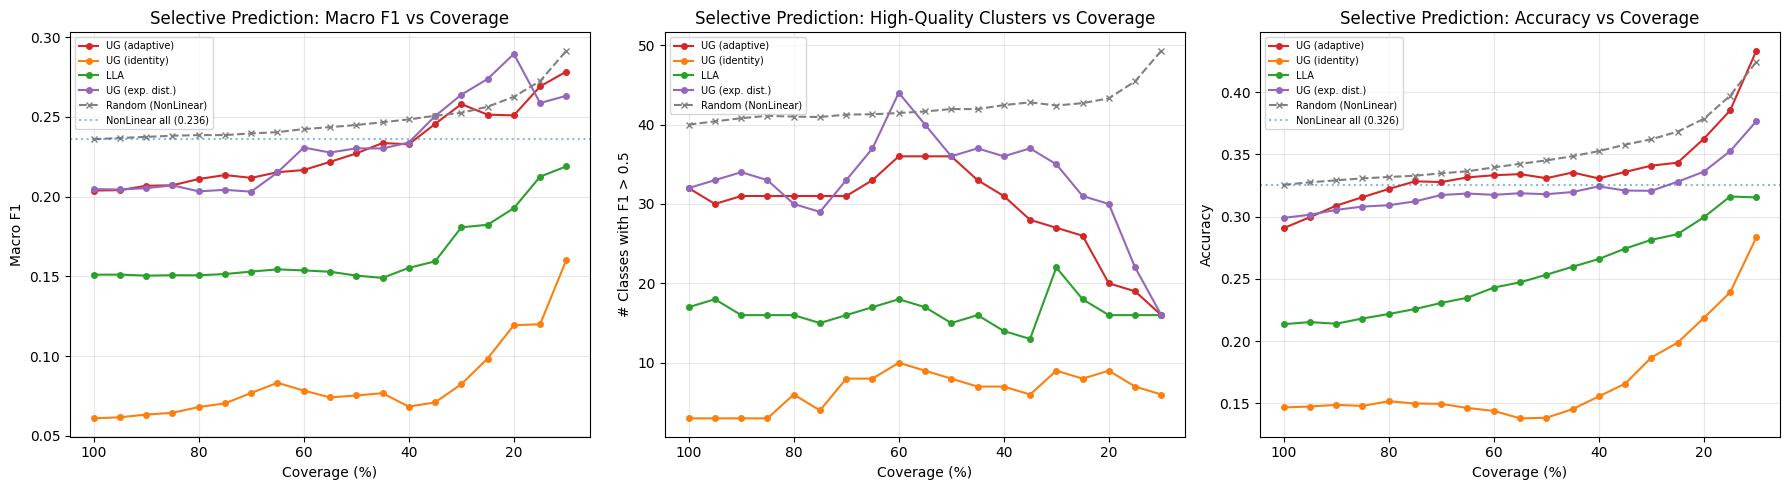


Model                F1@100%  F1@80%  F1@60%  F1@40%  |  Acc@100%  Acc@80%  Acc@60%  Acc@40%
------------------------------------------------------------------------------------------
UG (adaptive)         0.204   0.211   0.217   0.233  |   0.291   0.322   0.333   0.331
UG (identity)         0.061   0.068   0.078   0.068  |   0.147   0.152   0.144   0.155
LLA                   0.151   0.151   0.154   0.155  |   0.214   0.222   0.243   0.266
UG (exp. dist.)       0.205   0.203   0.231   0.234  |   0.299   0.309   0.318   0.324


In [24]:
# --- Selective prediction: does discarding high-variance samples improve F1 & accuracy? ---
# For each probabilistic model, sort samples by mean variance (uncertainty).
# At each coverage level, keep only the most confident samples and measure
# per-class F1 and accuracy on the retained subset using existing cluster assignments.

import sklearn.metrics

def selective_curves(true_labels, pred_labels, uncertainties, coverages):
    """Compute macro F1 and accuracy at each coverage level using uncertainty-based selection.
    
    Returns F1 scores, counts of classes with F1 > 0.5, and accuracy at each coverage.
    """
    n = len(true_labels)
    # Sort by uncertainty ascending (most confident first)
    order = np.argsort(uncertainties)
    
    f1_scores = []
    f1_gt05_counts = []
    acc_scores = []
    
    for cov in coverages:
        k = max(1, int(n * cov))
        keep = order[:k]
        
        tl = true_labels[keep]
        pl = pred_labels[keep]
        
        # Remove unassigned
        mask = pl != -1
        if mask.sum() < 2:
            f1_scores.append(0.0)
            f1_gt05_counts.append(0)
            acc_scores.append(0.0)
            continue
        
        tl_m, pl_m = tl[mask], pl[mask]
        
        # Hungarian alignment on this subset
        alignment = align_labels_via_hungarian_algorithm(tl_m, pl_m)
        aligned = np.array([alignment.get(p, -1) for p in pl_m])
        
        per_class_f1 = sklearn.metrics.f1_score(tl_m, aligned, average=None, zero_division=0)
        f1_scores.append(np.mean(per_class_f1))
        f1_gt05_counts.append(int((per_class_f1 > 0.5).sum()))
        acc_scores.append(np.mean(aligned == tl_m))
    
    return np.array(f1_scores), np.array(f1_gt05_counts), np.array(acc_scores)

coverages = np.linspace(1.0, 0.1, 19)  # 100%, 95%, ..., 10%

# Compute uncertainty per sample (mean variance across dimensions)
unc_ug_ad = emb_ug_ad.variance.mean(axis=1)
unc_ug_id = emb_ug_id.variance.mean(axis=1)
unc_lla = emb_lla.variance.mean(axis=1)
unc_ug_ed = emb_ug_ed.variance.mean(axis=1)

# Random baseline: average over multiple random orderings
rng_sel = np.random.RandomState(SEED)
n_random_trials = 20

models_selective = [
    ("UG (adaptive)", pred_ug_ad, unc_ug_ad, "tab:red"),
    ("UG (identity)", pred_ug_id, unc_ug_id, "tab:orange"),
    ("LLA",           pred_lla,   unc_lla,   "tab:green"),
    ("UG (exp. dist.)", pred_ug_ed, unc_ug_ed, "tab:purple"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, pred, unc, color in models_selective:
    f1_curve, f1_gt05, acc_curve = selective_curves(test_labels, pred, unc, coverages)
    axes[0].plot(coverages * 100, f1_curve, "o-", label=name, color=color, markersize=4)
    axes[1].plot(coverages * 100, f1_gt05, "o-", label=name, color=color, markersize=4)
    axes[2].plot(coverages * 100, acc_curve, "o-", label=name, color=color, markersize=4)

# Random baseline (use NonLinear predictions since it has the best clustering)
random_f1_all = []
random_gt05_all = []
random_acc_all = []
for trial in range(n_random_trials):
    rand_unc = rng_sel.rand(len(test_labels))
    f1_r, gt05_r, acc_r = selective_curves(test_labels, pred_nl, rand_unc, coverages)
    random_f1_all.append(f1_r)
    random_gt05_all.append(gt05_r)
    random_acc_all.append(acc_r)
random_f1_mean = np.mean(random_f1_all, axis=0)
random_gt05_mean = np.mean(random_gt05_all, axis=0)
random_acc_mean = np.mean(random_acc_all, axis=0)

axes[0].plot(coverages * 100, random_f1_mean, "x--", color="gray", label="Random (NonLinear)", markersize=4)
axes[1].plot(coverages * 100, random_gt05_mean, "x--", color="gray", label="Random (NonLinear)", markersize=4)
axes[2].plot(coverages * 100, random_acc_mean, "x--", color="gray", label="Random (NonLinear)", markersize=4)

# NonLinear full (constant reference line)
f1_nl_full = np.mean(r_nl["per_class_f1"])
axes[0].axhline(f1_nl_full, ls=":", color="tab:blue", alpha=0.5, label=f"NonLinear all ({f1_nl_full:.3f})")

# NonLinear accuracy reference
mask_nl = pred_nl != -1
align_nl = align_labels_via_hungarian_algorithm(test_labels[mask_nl], pred_nl[mask_nl])
aligned_nl = np.array([align_nl.get(p, -1) for p in pred_nl[mask_nl]])
acc_nl_full = np.mean(aligned_nl == test_labels[mask_nl])
axes[2].axhline(acc_nl_full, ls=":", color="tab:blue", alpha=0.5, label=f"NonLinear all ({acc_nl_full:.3f})")

axes[0].set_xlabel("Coverage (%)")
axes[0].set_ylabel("Macro F1")
axes[0].set_title("Selective Prediction: Macro F1 vs Coverage")
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()

axes[1].set_xlabel("Coverage (%)")
axes[1].set_ylabel("# Classes with F1 > 0.5")
axes[1].set_title("Selective Prediction: High-Quality Clusters vs Coverage")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()

axes[2].set_xlabel("Coverage (%)")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Selective Prediction: Accuracy vs Coverage")
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()

# Print summary at key coverage levels
key_covs = [100, 80, 60, 40]
print(f"\n{'Model':<20s} " + "  ".join(f"F1@{c}%" for c in key_covs) + "  |  " + "  ".join(f"Acc@{c}%" for c in key_covs))
print("-" * 90)
for name, pred, unc, _ in models_selective:
    f1_curve, _, acc_curve = selective_curves(test_labels, pred, unc, coverages)
    idx = {round(c * 100): i for i, c in enumerate(coverages)}
    f1_vals = "  ".join(f"{f1_curve[idx[c]]:6.3f}" for c in key_covs)
    acc_vals = "  ".join(f"{acc_curve[idx[c]]:6.3f}" for c in key_covs)
    print(f"{name:<20s} {f1_vals}  |  {acc_vals}")

**Observations:** UG adaptive shows the best selective prediction curves (F1 improves from 0.204 to 0.233, accuracy from 0.291 to 0.331 at 40% coverage), but this is confounded by it having the second-best clustering to begin with. The curves are hard to interpret because each model starts at a different F1/accuracy level reflecting its own clustering quality.

### Decoupled Selective Prediction

To isolate the **variance signal** from the **clustering quality**, we fix the clustering to NonLinear deterministic (the best) for all models and only vary the uncertainty signal used for rejection. The alignment is computed once at 100% coverage and reused at all levels to prevent alignment shifts from confounding the results.

**What to expect:** If a model's variance is positively correlated with prediction error, accuracy should increase as we discard high-variance samples (the uncertain samples are disproportionately wrong). The random baseline should be flat.

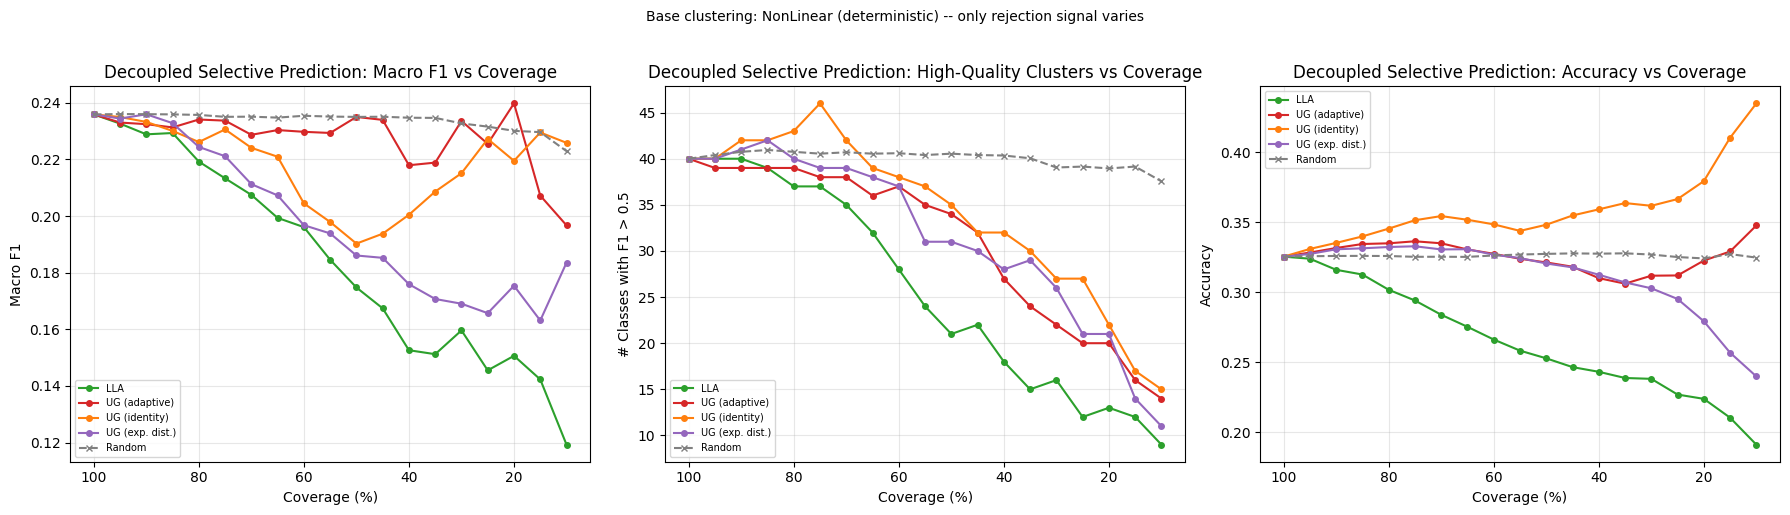


Base clustering: NonLinear deterministic (F1>0.5=40, k=121)
Uncertainty signal   F1@100%  F1@80%  F1@60%  F1@40%  |  Acc@100%  Acc@80%  Acc@60%  Acc@40%
------------------------------------------------------------------------------------------
LLA                   0.236   0.219   0.196   0.153  |   0.326   0.302   0.266   0.243
UG (adaptive)         0.236   0.234   0.230   0.218  |   0.326   0.335   0.328   0.310
UG (identity)         0.236   0.226   0.204   0.200  |   0.326   0.346   0.349   0.359
UG (exp. dist.)       0.236   0.224   0.197   0.176  |   0.326   0.332   0.327   0.313
Random                0.236   0.236   0.235   0.235  |   0.326   0.326   0.326   0.328


In [25]:
# --- Decoupled selective prediction: variance for rejection only, not clustering ---
# All models use the SAME base clustering (NonLinear deterministic, the best).
# Only the uncertainty signal varies -- this isolates "is the variance a good
# confidence measure?" from "is the probabilistic similarity good for clustering?"

# Fix alignment once from 100% coverage to avoid alignment shifts
mask_base = pred_nl != -1
base_alignment = align_labels_via_hungarian_algorithm(test_labels[mask_base], pred_nl[mask_base])

def selective_curves_fixed(true_labels, pred_labels, uncertainties, coverages, alignment):
    """Selective prediction with FIXED alignment (computed once at 100% coverage).
    
    Uses the same pre-computed alignment at every coverage level so that
    improvements come purely from discarding uncertain samples, not from
    the alignment problem getting easier.
    """
    n = len(true_labels)
    order = np.argsort(uncertainties)
    
    f1_scores, f1_gt05_counts, acc_scores = [], [], []
    
    for cov in coverages:
        k = max(1, int(n * cov))
        keep = order[:k]
        
        tl = true_labels[keep]
        pl = pred_labels[keep]
        
        mask = pl != -1
        if mask.sum() < 2:
            f1_scores.append(0.0)
            f1_gt05_counts.append(0)
            acc_scores.append(0.0)
            continue
        
        tl_m, pl_m = tl[mask], pl[mask]
        aligned = np.array([alignment.get(p, -1) for p in pl_m])
        
        per_class_f1 = sklearn.metrics.f1_score(tl_m, aligned, average=None, zero_division=0)
        f1_scores.append(np.mean(per_class_f1))
        f1_gt05_counts.append(int((per_class_f1 > 0.5).sum()))
        acc_scores.append(np.mean(aligned == tl_m))
    
    return np.array(f1_scores), np.array(f1_gt05_counts), np.array(acc_scores)

coverages_d = np.linspace(1.0, 0.1, 19)

models_decoupled = [
    ("LLA",           unc_lla,   "tab:green"),
    ("UG (adaptive)", unc_ug_ad, "tab:red"),
    ("UG (identity)", unc_ug_id, "tab:orange"),
    ("UG (exp. dist.)", unc_ug_ed, "tab:purple"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, unc, color in models_decoupled:
    f1_c, gt05_c, acc_c = selective_curves_fixed(
        test_labels, pred_nl, unc, coverages_d, base_alignment)
    axes[0].plot(coverages_d * 100, f1_c, "o-", label=name, color=color, markersize=4)
    axes[1].plot(coverages_d * 100, gt05_c, "o-", label=name, color=color, markersize=4)
    axes[2].plot(coverages_d * 100, acc_c, "o-", label=name, color=color, markersize=4)

# Random baseline (same base clustering, random rejection)
rng_d = np.random.RandomState(SEED)
rand_f1, rand_gt05, rand_acc = [], [], []
for _ in range(20):
    rand_unc = rng_d.rand(len(test_labels))
    f1_r, gt05_r, acc_r = selective_curves_fixed(
        test_labels, pred_nl, rand_unc, coverages_d, base_alignment)
    rand_f1.append(f1_r); rand_gt05.append(gt05_r); rand_acc.append(acc_r)

axes[0].plot(coverages_d * 100, np.mean(rand_f1, axis=0), "x--", color="gray",
             label="Random", markersize=4)
axes[1].plot(coverages_d * 100, np.mean(rand_gt05, axis=0), "x--", color="gray",
             label="Random", markersize=4)
axes[2].plot(coverages_d * 100, np.mean(rand_acc, axis=0), "x--", color="gray",
             label="Random", markersize=4)

for ax, ylabel, title in zip(axes,
        ["Macro F1", "# Classes with F1 > 0.5", "Accuracy"],
        ["Macro F1 vs Coverage", "High-Quality Clusters vs Coverage", "Accuracy vs Coverage"]):
    ax.set_xlabel("Coverage (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Decoupled Selective Prediction: {title}")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

plt.suptitle("Base clustering: NonLinear (deterministic) -- only rejection signal varies",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
key_covs = [100, 80, 60, 40]
print(f"\nBase clustering: NonLinear deterministic (F1>0.5={r_nl['counts'][4]}, k={k_nl})")
print(f"{'Uncertainty signal':<20s} " + "  ".join(f"F1@{c}%" for c in key_covs)
      + "  |  " + "  ".join(f"Acc@{c}%" for c in key_covs))
print("-" * 90)
for name, unc, _ in models_decoupled:
    f1_c, _, acc_c = selective_curves_fixed(
        test_labels, pred_nl, unc, coverages_d, base_alignment)
    idx = {round(c * 100): i for i, c in enumerate(coverages_d)}
    f1_v = "  ".join(f"{f1_c[idx[c]]:6.3f}" for c in key_covs)
    acc_v = "  ".join(f"{acc_c[idx[c]]:6.3f}" for c in key_covs)
    print(f"{name:<20s} {f1_v}  |  {acc_v}")
rand_f1_m = np.mean(rand_f1, axis=0)
rand_acc_m = np.mean(rand_acc, axis=0)
idx = {round(c * 100): i for i, c in enumerate(coverages_d)}
f1_v = "  ".join(f"{rand_f1_m[idx[c]]:6.3f}" for c in key_covs)
acc_v = "  ".join(f"{rand_acc_m[idx[c]]:6.3f}" for c in key_covs)
print(f"{'Random':<20s} {f1_v}  |  {acc_v}")

**Decoupled results** (all models use NonLinear clustering, only rejection signal varies):

| Uncertainty signal | Acc@100% | Acc@80% | Acc@60% | Acc@40% | Trend |
|---|---|---|---|---|---|
| UG (identity) | 0.326 | 0.346 | 0.349 | **0.359** | Improves |
| UG (adaptive) | 0.326 | 0.335 | 0.328 | 0.310 | Roughly flat |
| UG (expected dist.) | 0.326 | 0.332 | 0.327 | 0.313 | Roughly flat |
| LLA | 0.326 | 0.302 | 0.266 | 0.243 | **Worsens** (anti-correlated) |
| Random | 0.326 | 0.326 | 0.326 | 0.328 | Flat (baseline) |

**Key findings:**

1. **UG identity is the only useful confidence signal** -- accuracy improves from 0.326 to 0.359 at 40% coverage. Its variance, while small in magnitude, is positively correlated with prediction error.
2. **LLA variance is anti-correlated** -- worse than random at every coverage level. Discarding high-variance LLA samples actually removes the correct predictions. This is consistent with the B ~ cI analysis: LLA assigns high variance to samples with large hidden activations, which tend to be the well-separated (correct) ones.
3. **UG expected distance is roughly neutral** -- tracks near the random baseline similarly to UG adaptive (0.313 vs 0.310 at 40% coverage). Despite having the highest SNR among probabilistic models, the expected distance variance does not provide a useful per-sample confidence signal in the decoupled setting.
4. **UG adaptive is neutral** -- roughly tracks the random baseline. Its large per-dimension variances provide useful reweighting during training but not useful per-sample confidence at eval time.
5. **F1 decreases for all models** as coverage drops, because discarding samples removes class representatives, reducing the number of classes that can achieve high F1. Accuracy is the better metric for selective prediction.

## Why Probabilistic Similarity Fails for Clustering

### Two different kernels, two different failure modes

The probabilistic models use two different similarity formulas depending on the kernel form (K). Each fails for a distinct reason.

---

### Adaptive form (UG adaptive)

$$\text{sim}(i,j) = \exp\!\left(-s \sum_d \frac{(\mu_{i,d} - \mu_{j,d})^2}{\sigma^2_{i,d} + \sigma^2_{j,d}}\right)$$

Dividing by variance **shrinks** distances in high-variance dimensions. There is **no normalization penalty** -- the adaptive kernel $K = \alpha(\Sigma_i + \Sigma_j)$ cancels the log-determinant, making it constant across all variance levels.

**Effect on the 4 regimes:**

| Pair type | Euclidean | Adaptive Mahalanobis | Desired for clustering |
|---|---|---|---|
| Close + low var | moderate sim | moderate sim | **high sim** (confident & close) |
| Close + high var | moderate sim | **high sim** ^ | moderate sim (uncertain) |
| Far + low var | low sim | **very low sim** v | low sim (confident & far) |
| Far + high var | low sim | **moderate sim** ^ | low sim (uncertain & far) |

**Failure:** High variance inflates similarity to *all* neighbors (both correct and incorrect), causing spurious cluster merges. There is no penalty for being uncertain -- only per-dimension reweighting.

---

### Identity form (UG identity)

$$\text{dist}(i,j) = \sum_d \left[\tfrac{1}{2}\log\!\bigl(\sigma^2_{i,d} + \sigma^2_{j,d} + 1\bigr) + \frac{(\mu_{i,d} - \mu_{j,d})^2}{2\bigl(\sigma^2_{i,d} + \sigma^2_{j,d} + 1\bigr)}\right]$$
$$\text{sim}(i,j) = \exp(-s \cdot \text{dist})$$

This form includes a **log-normalization penalty**: the $\frac{1}{2}\log(\cdot)$ term increases distance whenever variance is nonzero. When $\sigma^2 = 0$, $\text{dist} = \frac{1}{2}\|\delta\|^2$ -- identical to deterministic L2. Any $\sigma^2 > 0$ adds a positive offset.

**Effect on the 4 regimes (opposite to adaptive!):**

| Pair type | Euclidean | Identity form | Desired for clustering |
|---|---|---|---|
| Close + low var | moderate sim | moderate sim (~ deterministic) | **high sim** (confident & close) |
| Close + high var | moderate sim | **lower sim** v (log penalty) | moderate sim (uncertain) |
| Far + low var | low sim | low sim (~ deterministic) | low sim (confident & far) |
| Far + high var | low sim | **even lower sim** v (log penalty) | low sim (uncertain & far) |

**Failure (different from adaptive):** Variance doesn't inflate similarity -- it always *deflates* it. The problem is **dynamic range compression**. With UG identity's small variances ($\bar{\sigma}^2 \approx 0.002$), the constant log offset across $D = 256$ dimensions is:

$$\sum_d \tfrac{1}{2}\log(0.004 + 1) \approx 0.512$$

This constant is added to *every* pair equally, compressing the ratio between inter-class and intra-class distances:
- **NonLinear (deterministic):** inter/intra ~ 20x -> clear separation  
- **UG identity:** inter/intra ~ 2.7x -> poor separation -> $k_\text{est}$ too low

The auto-calibrated scale $s = \ln 2 / \text{median}$ cannot fix this because the *relative* structure of the distance matrix is degraded.

---

### Why the "correct" fix (expected Gaussian kernel) fails

The theoretically correct alternative is the expected kernel:

$$E\bigl[e^{-s\|z_i - z_j\|^2}\bigr] = \prod_d \frac{1}{\sqrt{1+2s\,v_d}}\;\exp\!\left(\frac{-s\,\delta_d^2}{1+2s\,v_d}\right), \quad v_d = \sigma^2_{i,d}+\sigma^2_{j,d}$$

The $\prod 1/\sqrt{\cdot}$ term correctly penalizes high variance. However, this product over $D = 256$ dimensions is **exponentially small** -- e.g., for UG adaptive ($v \approx 1.3$, $s \approx 0.1$): $(1.26)^{-128} \approx 10^{-13}$. All similarities collapse to $\approx 0$ ($k_\text{est} = 1$).

---

### Practical conclusion

Neither probabilistic similarity formula improves clustering over the deterministic baseline:
- **Adaptive** inflates similarity for uncertain points (no normalization penalty)
- **Identity** compresses dynamic range via a constant log offset (normalization penalty too uniform)

Variance is most useful as a **per-sample confidence signal** for post-hoc selective prediction, not as a modifier of the pairwise distance. The decoupled experiment above confirms this: deterministic clustering + variance-based rejection yields accuracy improvements (UG identity: 0.326 -> 0.359) without the distortions introduced by probabilistic similarity.